# 🚢 Maritime AIS Behavior Classification — Final 48-Feature Training, Evaluation, and Diagnostics

This notebook uses the prepared AIS DS2 artifacts and trains the final 48-feature inference-safe model. The prepared data include two deployable, current/past-only features motivated by rule-signature diagnostics:

- `stop_tendency_score`: a past/current approximation of stopping tendency without using `future_stop_ratio`.
- `maneuver_intensity_score`: a course-change intensity score normalized by speed-change magnitude.

Reporting rule:

- The **raw ML model** uses only inference-safe current/past features.
- Rule-assisted / guarded hybrid variants are reported as **diagnostic only**, because the diagnostic rule flags can include future-window target-construction information such as `future_stop_ratio`.



Default prepared-data directory: `ais_ds2_prepared/balanced_train/`. The sibling `ais_ds2_prepared/final/` contains the unchanged, naturally imbalanced training split for diagnostics.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Presentation CSS + Toggle Button  (blue theme)
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display, Javascript

display(Javascript(r"""
(function() {

var css = `
  @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&family=Fira+Code:wght@400;500&display=swap');

  :root {
    --b50:#eff6ff; --b100:#dbeafe; --b200:#bfdbfe; --b400:#60a5fa;
    --b500:#3b82f6; --b600:#2563eb; --b700:#1d4ed8; --b800:#1e40af; --b900:#1e3a8a;
    --s50:#f8fafc;  --s100:#f1f5f9; --s200:#e2e8f0;
    --s600:#475569; --s700:#334155; --s800:#1e293b;
  }

  .jp-Notebook, #notebook-container { background: var(--s50) !important; }

  .jp-MarkdownOutput, .rendered_html, .text_cell_render {
    font-family: 'Inter', sans-serif !important; color: var(--s800); line-height: 1.75;
  }
  .jp-MarkdownOutput h1, .rendered_html h1, .text_cell_render h1 {
    font-size: 2.2rem; font-weight: 700; color: var(--b900);
    border-bottom: 4px solid var(--b500); padding-bottom: .4rem; margin-top: 1.5rem;
  }
  .jp-MarkdownOutput h2, .rendered_html h2, .text_cell_render h2 {
    font-size: 1.55rem; font-weight: 600; color: var(--b700);
    border-left: 5px solid var(--b500); padding-left: .75rem; margin-top: 2rem;
  }
  .jp-MarkdownOutput h3, .rendered_html h3, .text_cell_render h3 {
    font-size: 1.15rem; font-weight: 600; color: var(--b600); margin-top: 1.4rem;
  }
  .jp-MarkdownOutput blockquote, .rendered_html blockquote, .text_cell_render blockquote {
    background: var(--b50); border-left: 5px solid var(--b500);
    border-radius: 0 8px 8px 0; padding: 1rem 1.4rem;
    margin: 1rem 0; color: var(--s700); font-size: .97rem;
  }
  .jp-MarkdownOutput code, .rendered_html code, .text_cell_render code {
    font-family: 'Fira Code', monospace !important;
    background: var(--b100); color: var(--b900);
    padding: .1em .4em; border-radius: 4px; font-size: .88em;
  }
  .jp-MarkdownOutput table, .rendered_html table, .text_cell_render table {
    border-collapse: collapse; width: 100%; font-size: .93rem;
    border-radius: 8px; overflow: hidden; box-shadow: 0 1px 4px rgba(0,0,0,.08);
  }
  .jp-MarkdownOutput th, .rendered_html th, .text_cell_render th {
    background: var(--b700); color: white; padding: .6rem 1rem; text-align: left;
  }
  .jp-MarkdownOutput td, .rendered_html td, .text_cell_render td {
    padding: .5rem 1rem; border-bottom: 1px solid var(--s200);
  }
  .jp-MarkdownOutput tr:nth-child(even), .rendered_html tr:nth-child(even),
  .text_cell_render tr:nth-child(even) { background: var(--b50); }
  .jp-MarkdownOutput hr, .rendered_html hr, .text_cell_render hr {
    border: none; border-top: 2px solid var(--b200); margin: 2rem 0;
  }
  .jp-CodeCell .jp-Cell-inputWrapper,
  .code_cell .input { border-left: 3px solid var(--b400) !important; }
  .jp-OutputArea-output, .output_subarea { background: white; border-radius: 8px; }

  #nb-code-toggle {
    position: fixed !important; top: 18px !important; right: 24px !important;
    z-index: 999999 !important;
    background: linear-gradient(135deg, var(--b600), var(--b900));
    color: white; border: none; padding: 9px 20px; border-radius: 24px;
    font-family: 'Inter', sans-serif; font-size: .82rem; font-weight: 600;
    letter-spacing: .5px; cursor: pointer;
    box-shadow: 0 3px 12px rgba(37,99,235,.4);
    transition: transform .2s, box-shadow .2s;
  }
  #nb-code-toggle:hover { transform: translateY(-1px); box-shadow: 0 6px 18px rgba(37,99,235,.5); }

  .metric-grid {
    display: grid; grid-template-columns: repeat(auto-fit,minmax(150px,1fr));
    gap: 1rem; margin: 1.2rem 0;
  }
  .metric-card {
    background: white; border: 1px solid var(--b200); border-radius: 12px;
    padding: 1.1rem 1rem; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,.06);
  }
  .metric-card.best { border-color: var(--b500); background: var(--b50); }
  .metric-card .label {
    font-size: .75rem; font-weight: 600; text-transform: uppercase;
    letter-spacing: .8px; color: var(--b700); margin-bottom: .35rem;
  }
  .metric-card .value { font-size: 1.8rem; font-weight: 700; color: var(--s800); }
  .metric-card .sub  { font-size: .78rem; color: var(--s600); margin-top: .2rem; }
`;

var styleEl = document.getElementById('nb-presentation-style');
if (!styleEl) { styleEl = document.createElement('style'); styleEl.id = 'nb-presentation-style'; document.head.appendChild(styleEl); }
styleEl.textContent = css;

var existing = document.getElementById('nb-code-toggle');
if (existing) existing.remove();
var btn = document.createElement('button');
btn.id = 'nb-code-toggle';
btn.textContent = '⬇ Show Code';
var _hidden = true;

function getCodeInputs() {
  var els = Array.from(document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
  if (els.length === 0) els = Array.from(document.querySelectorAll('.code_cell .input'));
  return els;
}
btn.addEventListener('click', function() {
  _hidden = !_hidden;
  getCodeInputs().forEach(function(el) { el.style.display = _hidden ? 'none' : ''; });
  btn.textContent = _hidden ? '⬇ Show Code' : '⬆ Hide Code';
});
document.body.appendChild(btn);

function autoHide(retries) {
  var cells = getCodeInputs();
  if (cells.length > 0) { cells.forEach(function(el) { el.style.display = 'none'; }); _hidden = true; btn.textContent = '⬇ Show Code'; }
  else if (retries > 0) { setTimeout(function() { autoHide(retries - 1); }, 400); }
}
setTimeout(function() { autoHide(10); }, 600);

})();
"""))


<IPython.core.display.Javascript object>

---

## Notebook update note

This notebook evaluates AIS behavior classifiers using the prepared DS2 dataset. The executed validation run selected **XGBoost** as the best raw validation model by Macro F1.

There are two different result types in this notebook:

1. **Raw predictive ML result** — direct prediction from the trained classifier using the leakage-safe model features.
2. **Rule-assisted diagnostic / diagnostic rule-assisted result** — the raw prediction is corrected using diagnostic rule signatures and targeted guards.

The conservative priority rules evaluated in the optional hybrid diagnostics are:

```text
ACCEL+MANEUVER -> maneuver
DECEL+MANEUVER -> maneuver
STOP+DECEL     -> stop
```

`STOP+ACCEL` is intentionally **not** forced to `stop` in the conservative setting because the group is rare and ambiguous; forcing it would be an over-specific rule.

Important distinction:

- The **raw ML validation report** shows the selected trained model before post-processing.
- The **diagnostic rule-assisted validation reports** apply rule-priority and/or targeted guard corrections to the prediction vector and are kept as diagnostic experiments.
- The **final test section is now configured to report the clean raw ML model** with `FINAL_POSTPROCESS_MODE = "raw"`.

Validity caveat for reporting: the rule-priority and maneuver/decel guard variants use diagnostic columns such as `rule_signature`, `delta_mean_sog`, `future_stop_ratio`, and `turn_change_deg_abs`. These columns are connected to target-construction diagnostics and should not be reported as the main predictive ML result unless the same information is legitimately available at inference time. For the term-project submission, report the raw XGBoost result as the clean final model, and mention hybrid variants only as diagnostic/rule-assisted experiments.


## 📦 Section 1 — Setup & Load Persisted Training Data

We load the persisted artifacts created by the DS2 preprocessing notebook:

- `X_train`, `X_valid`, `X_test`
- `y_train`, `y_valid`, `y_test`
- `train_df`, `valid_df`, `test_df` for diagnostics
- `feature_cols.json`, `target_map.json`, `split_summary.json`

The diagnostic dataframes preserve metadata such as `MMSI`, `slice_start`, raw representative SOG/COG values, target-construction signals, and model features. This allows us to inspect suspicious errors after model evaluation.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports & global settings
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

# sklearn — models and preprocessing
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# sklearn — evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    roc_curve,
    auc,
)

# sklearn — validation and tuning
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.base import clone
from scipy.stats import randint, uniform, loguniform

SEED = 42
np.random.seed(SEED)

# Visual theme, compatible with instructor template style
BLUE   = "#2563eb"
BLUE_D = "#1e3a8a"
BLUE_L = "#bfdbfe"
SLATE  = "#475569"
RED    = "#dc2626"
GREEN  = "#16a34a"
ORANGE = "#f97316"
PURPLE = "#7c3aed"
GRAY   = "#64748b"
MODEL_COLORS = [BLUE, ORANGE, GREEN, PURPLE, RED, GRAY, "#0891b2", "#9333ea"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Libraries loaded.")

import matplotlib.ticker as mticker


Libraries loaded.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Configuration and robust file loading helpers
# ─────────────────────────────────────────────────────────────────────────────
# Default: public, stable prepared-data folder created by the DS2 preprocessing notebook.
# Validation and test are still unchanged; only the training split is downsampled.
FINAL_DIR = Path("ais_ds2_prepared/balanced_train")

# Alternative if you want to train on the original imbalanced training split:
# FINAL_DIR = Path("ais_ds2_prepared/final")

MODEL_DIR = FINAL_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Output folder used by final paper cross-check/export cells.
OUTPUT_DIR = MODEL_DIR / "paper_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Prepared data folder:", FINAL_DIR.resolve())


def load_df(name):
    """Load dataframe from CSV first, then Parquet/Pickle fallback."""
    csv_path = FINAL_DIR / f"{name}.csv"
    parquet_path = FINAL_DIR / f"{name}.parquet"
    pickle_path = FINAL_DIR / f"{name}.pkl"

    if csv_path.exists():
        return pd.read_csv(csv_path, low_memory=False)
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)

    raise FileNotFoundError(
        f"Could not find {name}.csv, {name}.parquet, or {name}.pkl under {FINAL_DIR.resolve()}"
    )


def load_json(name, default=None):
    path = FINAL_DIR / name
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return default


def squeeze_y(y_obj):
    """Accept y as Series/DataFrame and return a clean integer Series."""
    if isinstance(y_obj, pd.DataFrame):
        if "target_code" in y_obj.columns:
            y = y_obj["target_code"]
        elif y_obj.shape[1] == 1:
            y = y_obj.iloc[:, 0]
        else:
            raise ValueError(f"Cannot infer target column from y dataframe: {y_obj.columns.tolist()}")
    else:
        y = y_obj

    y = pd.Series(y).reset_index(drop=True)
    return y.astype(int)


def parse_datetime_columns(df):
    """Parse common datetime columns if they exist."""
    df = df.copy()
    for col in ["BaseDateTime", "slice_start", "slice_end"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


Prepared data folder: /Users/sedatakel/Konya_Gıda_ve_Tarım/CENG8003-Practical Data Science/Term_Project/Vessel Behavior Prediction /ais_ds2_prepared/balanced_train


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load persisted train / validation / test sets + diagnostic dataframes
# ─────────────────────────────────────────────────────────────────────────────
X_train = load_df("X_train")
X_valid = load_df("X_valid")
X_test  = load_df("X_test")

y_train = squeeze_y(load_df("y_train"))
y_valid = squeeze_y(load_df("y_valid"))
y_test  = squeeze_y(load_df("y_test"))

feature_cols = load_json("feature_cols.json", default=X_train.columns.tolist())
target_map = load_json("target_map.json", default=None)
split_summary = load_json("split_summary.json", default={})
balanced_summary = load_json("balanced_summary.json", default={})
preprocessing_update_summary = load_json("preprocessing_update_summary.json", default={})

# Diagnostic dataframes are produced by the preprocessing notebook.
# They are aligned row-by-row with X/y after reset_index in preprocessing.
try:
    train_df = parse_datetime_columns(load_df("train_df"))
    valid_df = parse_datetime_columns(load_df("valid_df"))
    test_df  = parse_datetime_columns(load_df("test_df"))
    HAS_DIAGNOSTIC_DF = True
except FileNotFoundError:
    # Fallback: diagnostics will still work on feature values, but no MMSI/time-neighborhood view.
    train_df = X_train.copy()
    valid_df = X_valid.copy()
    test_df  = X_test.copy()
    HAS_DIAGNOSTIC_DF = False

# Ensure same base feature order across all splits.
# The final paper version intentionally removes the earlier moving-steady binary
# conjunction feature and replaces the insight with two inference-safe continuous
# features computed only from current/past variables.
DROP_MODEL_FEATURES = ["is_moving_steady_candidate"]
for drop_col in DROP_MODEL_FEATURES:
    if drop_col in feature_cols:
        feature_cols.remove(drop_col)

X_train = X_train[feature_cols].reset_index(drop=True)
X_valid = X_valid[feature_cols].reset_index(drop=True)
X_test  = X_test[feature_cols].reset_index(drop=True)


def add_inference_safe_features(X, split_name="split"):
    """
    Add current/past-only deployable features.

    stop_tendency_score:
        Approximates whether the vessel is slowing toward a stop using only the
        current representative SOG and a past/current rolling SOG average.
        Positive values mean current speed is below recent rolling speed.

    maneuver_intensity_score:
        Measures course-change intensity normalized by the size of the speed
        change. It is set to 0 when COG is not reliable.
    """
    X = X.copy()
    eps = 0.1

    required_for_stop = ["rep_sog", "rep_sog_roll3"]
    required_for_maneuver = ["rep_cog_diff_lag1", "rep_sog_delta_1"]
    missing = [c for c in required_for_stop + required_for_maneuver if c not in X.columns]
    if missing:
        raise ValueError(f"{split_name}: cannot add inference-safe features; missing columns: {missing}")

    rep_sog = pd.to_numeric(X["rep_sog"], errors="coerce")
    rep_sog_roll3 = pd.to_numeric(X["rep_sog_roll3"], errors="coerce")
    rep_sog_delta_1 = pd.to_numeric(X["rep_sog_delta_1"], errors="coerce")
    rep_cog_diff_lag1 = pd.to_numeric(X["rep_cog_diff_lag1"], errors="coerce")

    stop_tendency = (rep_sog_roll3 - rep_sog) / (rep_sog_roll3 + eps)
    X["stop_tendency_score"] = (
        stop_tendency
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .clip(-5.0, 5.0)
    )

    maneuver_intensity = rep_cog_diff_lag1.abs() / (1.0 + rep_sog_delta_1.abs())
    if "cog_reliable" in X.columns:
        cog_reliable = pd.to_numeric(X["cog_reliable"], errors="coerce").fillna(0).astype(int).eq(1)
    else:
        # Fallback if old data lacks cog_reliable: only trust COG above maneuver minimum speed.
        fallback_min_valid_cog_sog = 1.0
        cog_reliable = rep_sog.fillna(0).ge(fallback_min_valid_cog_sog)

    X["maneuver_intensity_score"] = (
        maneuver_intensity
        .where(cog_reliable, 0.0)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .clip(0.0, 180.0)
    )

    return X


X_train = add_inference_safe_features(X_train, "train")
X_valid = add_inference_safe_features(X_valid, "valid")
X_test  = add_inference_safe_features(X_test, "test")

INFERENCE_SAFE_ADDED_FEATURES = ["stop_tendency_score", "maneuver_intensity_score"]
feature_cols = [c for c in feature_cols if c not in INFERENCE_SAFE_ADDED_FEATURES] + INFERENCE_SAFE_ADDED_FEATURES

# Keep diagnostic dataframes aligned and, where useful, add the same two feature
# columns for inspection/neighborhood displays. These columns are not future-based.
for _name, _df in [("train_df", train_df), ("valid_df", valid_df), ("test_df", test_df)]:
    try:
        _added = add_inference_safe_features(_df[[c for c in feature_cols if c in _df.columns]].copy(), _name)
        for _col in INFERENCE_SAFE_ADDED_FEATURES:
            if _col in _added.columns:
                _df[_col] = _added[_col].values
    except Exception:
        # Diagnostics can still run without these columns in *_df because the model
        # feature matrices already contain them.
        pass

# Final ordering after feature additions.
X_train = X_train[feature_cols].reset_index(drop=True)
X_valid = X_valid[feature_cols].reset_index(drop=True)
X_test  = X_test[feature_cols].reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_valid = y_valid.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Target mapping
if target_map is None:
    # Fallback based on project convention
    target_order = ["steady", "stop", "accelerate", "decelerate", "maneuver"]
    target_map = {name: i for i, name in enumerate(target_order)}

id_to_label = {int(v): k for k, v in target_map.items()}
label_to_id = {v: k for k, v in id_to_label.items()}
CLASS_IDS = sorted(id_to_label.keys())
CLASS_NAMES = [id_to_label[i] for i in CLASS_IDS]

# ─────────────────────────────────────────────────────────────────────────────
# Fallback-only diagnostic helpers
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTANT:
# Label repair and low-speed COG masking are now handled in the preprocessing
# notebook. This training notebook must not change y_train/y_valid/y_test or
# mutate model features after loading, otherwise the persisted data would no
# longer be the single source of truth.
#
# The helper below is only for old prepared datasets that do not yet contain
# rule_signature / rule-overlap columns. It is not used when the updated
# preprocessing notebook has already persisted those columns.

STOP_SOG_THRESHOLD = 0.5
STOP_RATIO_THRESHOLD = 0.80
MIN_VALID_COG_SOG = 1.0
MANEUVER_TURN_THRESHOLD_DEG = 45.0
STRONG_MANEUVER_TURN_THRESHOLD_DEG = 60.0
EXTREME_MANEUVER_TURN_THRESHOLD_DEG = 90.0
STRONG_LAG_COG_JUMP_DEG = 90.0


def _num_col(df, col, default=np.nan):
    """Return a numeric Series aligned to df even when col is missing."""
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index, dtype="float64")


def add_behavior_rule_flags(df):
    """
    Fallback rule-evidence diagnostics for older prepared datasets.

    IMPORTANT: this diagnostic helper can use future_stop_ratio for is_stop_rule;
    therefore rule-assisted/guarded outputs are diagnostic-only, not deployable inference.

    Updated preprocessing should already persist these columns:
    rule_signature, rule_overlap_count, is_*_rule, maneuver_strength_bin,
    strong_lag_cog_jump_flag, and cog_reliable.
    """
    df = df.copy()

    rep_sog = _num_col(df, "rep_sog")
    roll2 = _num_col(df, "rep_sog_roll2")
    roll3 = _num_col(df, "rep_sog_roll3")
    future_stop_ratio = _num_col(df, "future_stop_ratio")

    stop_by_ratio = future_stop_ratio.notna() & (future_stop_ratio >= STOP_RATIO_THRESHOLD)
    stop_by_zero_speed = (
        rep_sog.notna() &
        (rep_sog <= STOP_SOG_THRESHOLD) &
        (roll2.fillna(rep_sog) <= STOP_SOG_THRESHOLD) &
        (roll3.fillna(rep_sog) <= STOP_SOG_THRESHOLD)
    )
    df["is_stop_rule"] = stop_by_ratio | stop_by_zero_speed

    accel_threshold = _num_col(df, "accel_threshold_used")
    decel_threshold = _num_col(df, "decel_threshold_used")
    delta_mean_sog = _num_col(df, "delta_mean_sog")
    d1 = _num_col(df, "rep_sog_delta_1")
    d2 = _num_col(df, "rep_sog_delta_2")
    fallback_delta = pd.concat([d1, d2], axis=1)

    effective_accel_delta = delta_mean_sog.fillna(fallback_delta.max(axis=1))
    effective_decel_delta = delta_mean_sog.fillna(fallback_delta.min(axis=1))

    df["is_accel_rule"] = (
        effective_accel_delta.notna() &
        accel_threshold.notna() &
        (effective_accel_delta >= accel_threshold)
    )
    df["is_decel_rule"] = (
        effective_decel_delta.notna() &
        decel_threshold.notna() &
        (effective_decel_delta <= -decel_threshold)
    )

    turn_change = _num_col(df, "turn_change_deg_abs")
    df["is_maneuver_rule"] = (
        turn_change.notna() &
        rep_sog.notna() &
        (rep_sog >= MIN_VALID_COG_SOG) &
        (turn_change >= MANEUVER_TURN_THRESHOLD_DEG)
    )

    lag1 = _num_col(df, "rep_cog_diff_lag1").abs()
    lag2 = _num_col(df, "rep_cog_diff_lag2").abs()
    df["strong_lag_cog_jump_flag"] = (
        (rep_sog >= MIN_VALID_COG_SOG) &
        ((lag1 >= STRONG_LAG_COG_JUMP_DEG) | (lag2 >= STRONG_LAG_COG_JUMP_DEG))
    )

    rule_cols = ["is_stop_rule", "is_accel_rule", "is_decel_rule", "is_maneuver_rule"]
    df["rule_overlap_count"] = df[rule_cols].sum(axis=1)

    def _signature(row):
        parts = []
        if row["is_stop_rule"]:
            parts.append("STOP")
        if row["is_accel_rule"]:
            parts.append("ACCEL")
        if row["is_decel_rule"]:
            parts.append("DECEL")
        if row["is_maneuver_rule"]:
            parts.append("MANEUVER")
        return "+".join(parts) if parts else "STEADY"

    df["rule_signature"] = df.apply(_signature, axis=1)

    df["maneuver_strength_bin"] = pd.cut(
        turn_change,
        bins=[-np.inf, MANEUVER_TURN_THRESHOLD_DEG, STRONG_MANEUVER_TURN_THRESHOLD_DEG, EXTREME_MANEUVER_TURN_THRESHOLD_DEG, np.inf],
        labels=["below_threshold", "borderline_45_60", "strong_60_90", "extreme_gt_90"],
    )

    df["cog_reliable"] = (rep_sog >= MIN_VALID_COG_SOG).astype(int)
    return df


# Add rule diagnostics only if the loaded prepared data is old and missing them.
if HAS_DIAGNOSTIC_DF and "rule_signature" not in valid_df.columns:
    print("rule_signature not found in prepared diagnostic data; computing fallback diagnostics in training notebook.")
    train_df = add_behavior_rule_flags(train_df)
    valid_df = add_behavior_rule_flags(valid_df)
    test_df = add_behavior_rule_flags(test_df)

# Alignment checks: y files should match diagnostic dataframes when target_code is present.
for split_name, y_split, df_split in [
    ("train", y_train, train_df),
    ("valid", y_valid, valid_df),
    ("test", y_test, test_df),
]:
    if "target_code" in df_split.columns:
        df_target = pd.to_numeric(df_split["target_code"], errors="coerce").astype("Int64")
        mismatch = (df_target.astype("float64") != pd.Series(y_split).astype("float64")).fillna(False)
        if mismatch.any():
            raise ValueError(
                f"{split_name}: y_{split_name} is not aligned with {split_name}_df['target_code']. "
                f"Mismatched rows: {int(mismatch.sum())}"
            )

print("Data loaded successfully.")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | train_df: {train_df.shape}")
print(f"X_valid: {X_valid.shape} | y_valid: {y_valid.shape} | valid_df: {valid_df.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape} | test_df : {test_df.shape}")
print("Diagnostic dataframes available:", HAS_DIAGNOSTIC_DF)
print("\nClasses:", id_to_label)

if split_summary:
    print("\nSplit summary:")
    display(pd.Series(split_summary))

if balanced_summary:
    print("\nBalanced summary:")
    display(pd.Series(balanced_summary))

if preprocessing_update_summary:
    print("\nPreprocessing update summary:")
    display(pd.Series(preprocessing_update_summary))
else:
    print("\nNo preprocessing_update_summary.json found. This may be an older prepared dataset.")

if HAS_DIAGNOSTIC_DF and "rule_signature" in valid_df.columns:
    print("\nRule signature distribution in validation split:")
    display(valid_df["rule_signature"].value_counts(dropna=False).to_frame("count").head(20))

print("\nFeature count:", len(feature_cols))
print("Contains cog_reliable feature:", "cog_reliable" in feature_cols)
steady_feature_cols = [
    "abs_rep_sog_delta_1", "abs_rep_sog_delta_2",
    "abs_rep_cog_diff_lag1", "abs_rep_cog_diff_lag2",
    "sog_stability_score", "cog_stability_score", "motion_stability_score",
    "rep_sog_roll3_std", "stop_tendency_score", "maneuver_intensity_score",
]
print("Steady/stability feature coverage:")
for c in steady_feature_cols:
    print(f" - {c}: {c in feature_cols}")
display(X_train.head())

if HAS_DIAGNOSTIC_DF:
    print("\nDiagnostic validation columns sample:")
    print(valid_df.columns.tolist()[:80])


Data loaded successfully.
X_train: (6625, 48) | y_train: (6625,) | train_df: (6625, 90)
X_valid: (16096, 48) | y_valid: (16096,) | valid_df: (16096, 90)
X_test : (14560, 48) | y_test : (14560,) | test_df : (14560, 90)
Diagnostic dataframes available: True

Classes: {0: 'steady', 1: 'stop', 2: 'accelerate', 3: 'decelerate', 4: 'maneuver'}

Split summary:


split_mode                                                          mmsi_held_out
random_state                                                                   42
valid_test_size                                                               0.3
test_size_within_temp                                                         0.5
train_shape                                                           [60365, 48]
valid_shape                                                           [16096, 48]
test_shape                                                            [14560, 48]
train_mmsi_count                                                              274
valid_mmsi_count                                                               59
test_mmsi_count                                                                59
target_map                      {'steady': 0, 'stop': 1, 'accelerate': 2, 'dec...
feature_cols                    [rep_sog, rep_cog, sog_mean, sog_std, sog_min,...
preprocessing_up


Balanced summary:


source_dir                                                 ais_ds2_prepared/final
balanced_dir                                      ais_ds2_prepared/balanced_train
strategy                                   downsample_majority_classes_train_only
random_seed                                                                    42
min_class_count                                                              1325
original_train_shape                                                  [60365, 48]
balanced_train_shape                                                   [6625, 48]
original_train_class_counts     {'0': 1325, '1': 49583, '2': 2159, '3': 2625, ...
balanced_train_class_counts     {'0': 1325, '1': 1325, '2': 1325, '3': 1325, '...
target_map                      {'steady': 0, 'stop': 1, 'accelerate': 2, 'dec...
feature_cols                    [rep_sog, rep_cog, sog_mean, sog_std, sog_min,...
preprocessing_update_summary    {'experiment': 'MODERATE_STEADY_LABEL', 'moder...
dtype: object


Preprocessing update summary:


...


Rule signature distribution in validation split:


,count
rule_signature,
STOP,14084
DECEL,476
ACCEL,462
STOP+DECEL,282
STEADY,251
DECEL+MANEUVER,240
ACCEL+MANEUVER,209
MANEUVER,92



Feature count: 48
Contains cog_reliable feature: True
Steady/stability feature coverage:
 - abs_rep_sog_delta_1: True
 - abs_rep_sog_delta_2: True
 - abs_rep_cog_diff_lag1: True
 - abs_rep_cog_diff_lag2: True
 - sog_stability_score: True
 - cog_stability_score: True
 - motion_stability_score: True
 - rep_sog_roll3_std: True
 - stop_tendency_score: True
 - maneuver_intensity_score: True


,rep_sog,rep_cog,sog_mean,sog_std,sog_min,sog_max,cog_circular_std,n_msgs,coverage_seconds,cog_valid_for_maneuver,...,cog_stability_score,motion_stability_score,rep_sog_roll3_std,hour_sin,hour_cos,dow_sin,dow_cos,cog_reliable,stop_tendency_score,maneuver_intensity_score
0,10.2,290.924952,10.2125,0.064087,10.1,10.3,1.105388e+00,8,531.0,1,...,125.404085,7.908082,2.778489,1.224647e-16,-1.000000,-0.781831,0.623490,1,-0.450704,14.770825
1,9.0,233.685714,9.0000,0.057735,8.9,9.1,2.799419e-01,7,510.0,1,...,184.547520,12.690950,5.196152,9.659258e-01,0.258819,0.433884,-0.900969,1,-1.935484,12.861429
2,0.0,0.000000,0.0000,NaN,0.0,0.0,0.000000e+00,1,0.0,0,...,0.000000,0.110000,0.000000,8.660254e-01,-0.500000,-0.781831,0.623490,0,0.000000,0.000000
3,1.8,4.660450,1.7750,0.148805,1.5,1.9,1.195911e+01,8,560.0,1,...,71.871695,2.737434,0.750555,-9.659258e-01,0.258819,-0.781831,0.623490,1,0.185714,19.987844
4,4.2,65.100000,4.2000,NaN,4.2,4.2,8.537736e-07,1,0.0,1,...,109.018785,4.580376,1.385641,-8.660254e-01,0.500000,-0.781831,0.623490,1,0.156863,12.364713



Diagnostic validation columns sample:
['MMSI', 'slice_start', 'n_msgs', 'first_ts_in_slice', 'last_ts_in_slice', 'rep_sog', 'sog_mean', 'sog_std', 'sog_min', 'sog_max', 'rep_cog', 'cog_circular_std', 'slice_end', 'coverage_seconds', 'has_data', 'enough_data_for_repr', 'cog_valid_for_maneuver', 'past_nonempty_count', 'future_nonempty_count', 'past_mean_rep_sog', 'future_mean_rep_sog', 'delta_mean_sog', 'past_std_rep_sog', 'future_std_rep_sog', 'past_range_rep_sog', 'future_range_rep_sog', 'future_stop_ratio', 'past_cog_valid_count', 'future_cog_valid_count', 'past_mean_rep_cog', 'future_mean_rep_cog', 'past_std_rep_cog', 'future_std_rep_cog', 'turn_change_deg', 'turn_change_deg_abs', 'accel_threshold_used', 'decel_threshold_used', 'speed_regime', 'target_class', 'target_code', 'rep_sog_lag1', 'rep_cog_lag1', 'n_msgs_lag1', 'coverage_seconds_lag1', 'cog_valid_for_maneuver_lag1', 'rep_sog_lag2', 'rep_cog_lag2', 'n_msgs_lag2', 'coverage_seconds_lag2', 'cog_valid_for_maneuver_lag2', 'rep_s

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3B — Inference-safe feature check
# ─────────────────────────────────────────────────────────────────────────────
assert "is_moving_steady_candidate" not in feature_cols, "Removed steady-flag feature is still in feature_cols."
assert "is_moving_steady_candidate" not in X_train.columns, "Removed steady-flag feature is still in X_train."
for col in ["stop_tendency_score", "maneuver_intensity_score"]:
    assert col in feature_cols, f"Missing new feature in feature_cols: {col}"
    assert col in X_train.columns and col in X_valid.columns and col in X_test.columns, f"Missing new feature matrix column: {col}"

future_like_cols = [c for c in feature_cols if c.startswith("future_") or "future" in c.lower()]
assert not future_like_cols, f"Future-looking columns found in model features: {future_like_cols}"

print("Inference-safe feature check passed.")
print("Final model feature count:", len(feature_cols))
print("Added features:", INFERENCE_SAFE_ADDED_FEATURES)
print("Removed features:", DROP_MODEL_FEATURES)
display(X_train[INFERENCE_SAFE_ADDED_FEATURES].describe().T)


Inference-safe feature check passed.
Final model feature count: 48
Added features: ['stop_tendency_score', 'maneuver_intensity_score']
Removed features: ['is_moving_steady_candidate']


,count,mean,std,min,25%,50%,75%,max
stop_tendency_score,6625.0,-0.082331,0.489705,-1.973333,-0.127517,0.000000,0.067179,0.989583
maneuver_intensity_score,6625.0,16.499711,30.660177,0.000000,0.000000,4.590887,15.444559,178.937535


---

## ✂️ Section 2 — Dataset Overview & Class Imbalance

Because AIS behavior classes are naturally imbalanced, plain accuracy can be misleading. For this project, the more important metrics are:

- **Macro F1**: treats each class equally.
- **Balanced Accuracy**: average recall across classes.
- **Per-class recall**: especially for rare classes such as `maneuver`, `accelerate`, and `decelerate`.

The split mode is read from `split_summary.json`. If the preprocessing notebook used `SPLIT_BY_MMSI=True`, validation/test vessels are held out by MMSI. If it used `False`, the split is row-level stratified.


,class_id,class_name,count,proportion,split
0,0,steady,1325,0.2000,Train
1,1,stop,1325,0.2000,Train
2,2,accelerate,1325,0.2000,Train
3,3,decelerate,1325,0.2000,Train
4,4,maneuver,1325,0.2000,Train
5,0,steady,247,0.0153,Validation
6,1,stop,14364,0.8924,Validation
7,2,accelerate,458,0.0285,Validation
8,3,decelerate,471,0.0293,Validation
9,4,maneuver,556,0.0345,Validation


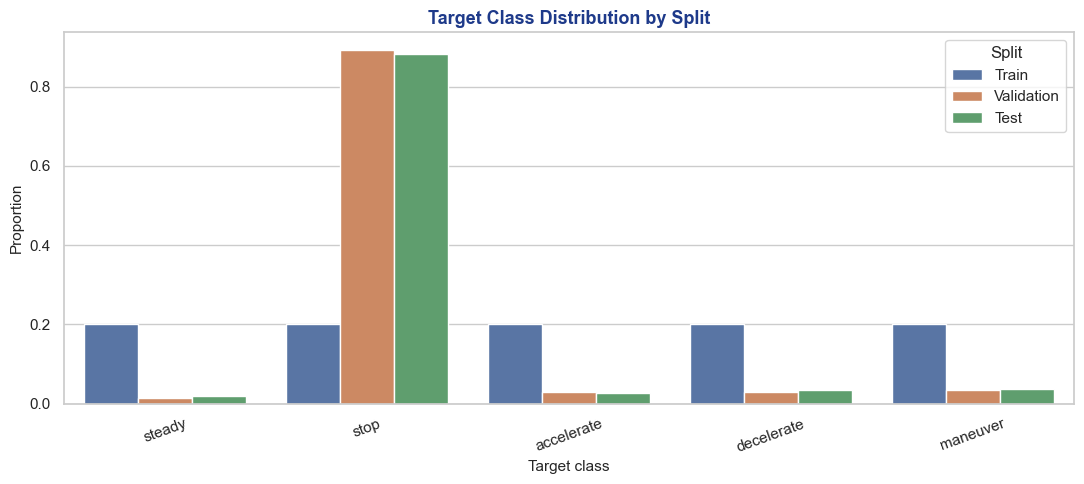

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Class distribution across splits
# ─────────────────────────────────────────────────────────────────────────────
def target_distribution(y, split_name):
    vc = y.value_counts().sort_index()
    out = pd.DataFrame({
        "class_id": vc.index,
        "class_name": [id_to_label.get(int(i), str(i)) for i in vc.index],
        "count": vc.values,
        "proportion": (vc.values / len(y)).round(4),
        "split": split_name,
    })
    return out

dist_df = pd.concat([
    target_distribution(y_train, "Train"),
    target_distribution(y_valid, "Validation"),
    target_distribution(y_test, "Test"),
], ignore_index=True)

display(dist_df)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=dist_df,
    x="class_name",
    y="proportion",
    hue="split",
    ax=ax,
)
ax.set_title("Target Class Distribution by Split", fontweight="bold", color=BLUE_D)
ax.set_xlabel("Target class")
ax.set_ylabel("Proportion")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Split")
plt.tight_layout()
plt.show()


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Missing values and feature sanity check
# ─────────────────────────────────────────────────────────────────────────────
missing_summary = pd.DataFrame({
    "feature": feature_cols,
    "train_missing_ratio": X_train[feature_cols].isna().mean().values,
    "valid_missing_ratio": X_valid[feature_cols].isna().mean().values,
    "test_missing_ratio": X_test[feature_cols].isna().mean().values,
}).sort_values("train_missing_ratio", ascending=False)

print("Feature dtype summary:")
print(X_train.dtypes.value_counts())

print("\nTop missing ratios:")
display(missing_summary.head(15))

print("\nAny non-numeric columns?")
non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print(non_numeric if non_numeric else "No non-numeric columns found.")


Feature dtype summary:
float64    42
int64       6
Name: count, dtype: int64

Top missing ratios:


,feature,train_missing_ratio,valid_missing_ratio,test_missing_ratio
3,sog_std,0.073660,0.199118,0.121429
21,coverage_seconds_lag3,0.061434,0.010810,0.012088
18,n_msgs_lag3,0.061434,0.010810,0.012088
12,rep_sog_lag3,0.061434,0.010810,0.012088
15,rep_cog_lag3,0.060377,0.007890,0.010302
34,abs_rep_sog_delta_2,0.043623,0.007269,0.008104
26,rep_sog_delta_2,0.043623,0.007269,0.008104
20,coverage_seconds_lag2,0.043623,0.007269,0.008104
11,rep_sog_lag2,0.043623,0.007269,0.008104
17,n_msgs_lag2,0.043623,0.007269,0.008104



Any non-numeric columns?
No non-numeric columns found.


---

## 🤖 Section 3 — Model Training

The data is already split into train/validation/test. We train models on `X_train`, compare them on `X_valid`, then reserve `X_test` for final evaluation.

The notebook includes scalable models suitable for this AIS dataset:

| Model | Role |
|---|---|
| Dummy Classifier | Baseline: majority-class reference |
| Logistic Regression | Linear baseline, class-weighted |
| Decision Tree | Simple interpretable nonlinear model |
| Random Forest | Bagging ensemble baseline |
| Extra Trees | Fast tree ensemble |
| HistGradientBoosting | Efficient gradient boosting |
| XGBoost | Optional, used if installed |


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Optional sampling controls for faster experiments
# ─────────────────────────────────────────────────────────────────────────────
# Set QUICK_MODE=True for fast classroom/demo runs.
# Set QUICK_MODE=False for full project runs.
QUICK_MODE = False
MAX_TRAIN_ROWS = 150_000 if QUICK_MODE else None


def make_training_sample(X, y, max_rows=None, seed=SEED):
    if max_rows is None or len(X) <= max_rows:
        return X, y

    tmp = X.copy()
    tmp["__target__"] = y.values
    sampled = (
        tmp.groupby("__target__", group_keys=False)
           .apply(lambda g: g.sample(
               n=max(1, int(max_rows * len(g) / len(tmp))),
               random_state=seed
           ))
           .sample(frac=1.0, random_state=seed)
    )
    y_s = sampled["__target__"].astype(int).reset_index(drop=True)
    X_s = sampled.drop(columns="__target__").reset_index(drop=True)
    return X_s, y_s

X_train_fit, y_train_fit = make_training_sample(X_train, y_train, MAX_TRAIN_ROWS)
print("Training data used for model fitting:", X_train_fit.shape, y_train_fit.shape)
print("QUICK_MODE:", QUICK_MODE)


Training data used for model fitting: (6625, 48) (6625,)
QUICK_MODE: False


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Define classifiers
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
models = {
    "Dummy Majority": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="saga",
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED,
        )),
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=SEED,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.05,
        random_state=SEED,
    ),
}

# Optional XGBoost support
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_IDS),
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
    print("XGBoost detected and added.")
except Exception as e:
    print("XGBoost not available; skipping XGBoost model.")

print("Models:")
for name in models:
    print(" -", name)


XGBoost detected and added.
Models:
 - Dummy Majority
 - Logistic Regression
 - Decision Tree
 - Random Forest
 - Extra Trees
 - Hist Gradient Boosting
 - XGBoost


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Train all models
# ─────────────────────────────────────────────────────────────────────────────
trained = {}
fit_times = {}

# Sample weights are kept for compatibility with imbalanced training folders.
# In the balanced_train folder they are effectively uniform.
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_fit)

for name, model in models.items():
    print(f"Training {name} ...")
    start = time.time()

    if name == "XGBoost":
        model.fit(X_train_fit, y_train_fit, sample_weight=sample_weight)
    else:
        model.fit(X_train_fit, y_train_fit)

    elapsed = time.time() - start
    trained[name] = model
    fit_times[name] = elapsed
    print(f"  done in {elapsed:.1f} sec")

print("\nTraining complete.")


Training Dummy Majority ...
  done in 0.0 sec
Training Logistic Regression ...
  done in 2.7 sec
Training Decision Tree ...
  done in 0.1 sec
Training Random Forest ...
  done in 0.5 sec
Training Extra Trees ...
  done in 0.1 sec
Training Hist Gradient Boosting ...
  done in 7.8 sec
Training XGBoost ...
  done in 2.7 sec

Training complete.


---

## 📊 Section 4 — Validation Evaluation

We select models using the validation set. The test set remains untouched until the final section.

For this multi-class behavior prediction problem, the main ranking metric is **Macro F1**, because it gives rare behavior classes equal importance instead of letting the majority `stop` class dominate the score.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Evaluation helper functions
# ─────────────────────────────────────────────────────────────────────────────
def aligned_predict_proba(model, X):
    """Return probabilities aligned to CLASS_IDS where possible."""
    if not hasattr(model, "predict_proba"):
        return None

    proba = model.predict_proba(X)

    # Some estimators may omit classes if trained on a sample without every class.
    if hasattr(model, "classes_"):
        model_classes = model.classes_
    elif hasattr(model, "named_steps") and hasattr(model.named_steps.get("model"), "classes_"):
        model_classes = model.named_steps["model"].classes_
    else:
        model_classes = np.array(CLASS_IDS)

    aligned = np.zeros((len(X), len(CLASS_IDS)))
    for j, cls in enumerate(model_classes):
        if int(cls) in CLASS_IDS:
            aligned[:, CLASS_IDS.index(int(cls))] = proba[:, j]

    # Avoid all-zero rows if something unexpected happens.
    row_sum = aligned.sum(axis=1)
    bad = row_sum == 0
    if bad.any():
        aligned[bad, :] = 1.0 / len(CLASS_IDS)
        row_sum = aligned.sum(axis=1)
    aligned = aligned / row_sum[:, None]
    return aligned


def evaluate_model(model, X, y, split_name="Validation"):
    y_pred = model.predict(X)
    proba = aligned_predict_proba(model, X)

    out = {
        "Accuracy": accuracy_score(y, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y, y_pred),
        "Macro Precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y, y_pred, average="weighted", zero_division=0),
    }

    if proba is not None:
        try:
            out["Log Loss"] = log_loss(y, proba, labels=CLASS_IDS)
        except Exception:
            out["Log Loss"] = np.nan
        try:
            out["ROC-AUC OVR Macro"] = roc_auc_score(y, proba, labels=CLASS_IDS, multi_class="ovr", average="macro")
        except Exception:
            out["ROC-AUC OVR Macro"] = np.nan
    else:
        out["Log Loss"] = np.nan
        out["ROC-AUC OVR Macro"] = np.nan

    return out


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Compute validation metrics for every model
# ─────────────────────────────────────────────────────────────────────────────
results = []

for name, model in trained.items():
    row = evaluate_model(model, X_valid, y_valid, split_name="Validation")
    row["Model"] = name
    row["Fit Time Sec"] = fit_times[name]
    results.append(row)

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("Macro F1", ascending=False)
)

display(results_df.round(4))

best_validation_name = results_df.index[0]
best_validation_model = trained[best_validation_name]

# For the final paper, retain XGBoost as the primary classifier for continuity,
# feature-importance interpretability, and comparable validation performance.
PAPER_MODEL_NAME = "XGBoost"
if PAPER_MODEL_NAME in trained:
    best_name = PAPER_MODEL_NAME
else:
    best_name = best_validation_name
best_model = trained[best_name]

print(f"Best validation model by Macro F1: {best_validation_name}")
print(f"Primary paper model used for detailed analysis: {best_name}")
if best_name != best_validation_name:
    print(f"Validation Macro F1 difference: {results_df.loc[best_validation_name, 'Macro F1'] - results_df.loc[best_name, 'Macro F1']:.4f}")


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss,ROC-AUC OVR Macro,Fit Time Sec
Model,,,,,,,,,
XGBoost,0.9570,0.8142,0.7270,0.8142,0.7653,0.9590,0.1329,0.9928,2.6601
Hist Gradient Boosting,0.9539,0.8128,0.7159,0.8128,0.7590,0.9564,0.1749,0.9924,7.8390
Random Forest,0.9540,0.7815,0.6971,0.7815,0.7331,0.9555,0.1427,0.9909,0.4749
Extra Trees,0.9499,0.7520,0.6615,0.7520,0.6966,0.9504,0.1678,0.9895,0.1483
Decision Tree,0.9428,0.7476,0.6537,0.7476,0.6876,0.9469,0.3233,0.9823,0.1038
Logistic Regression,0.9330,0.6473,0.5505,0.6473,0.5732,0.9330,0.2202,0.9806,2.6883
Dummy Majority,0.0153,0.2000,0.0031,0.2000,0.0060,0.0005,35.4905,0.5000,0.0011


Best validation model by Macro F1: XGBoost
Primary paper model used for detailed analysis: XGBoost


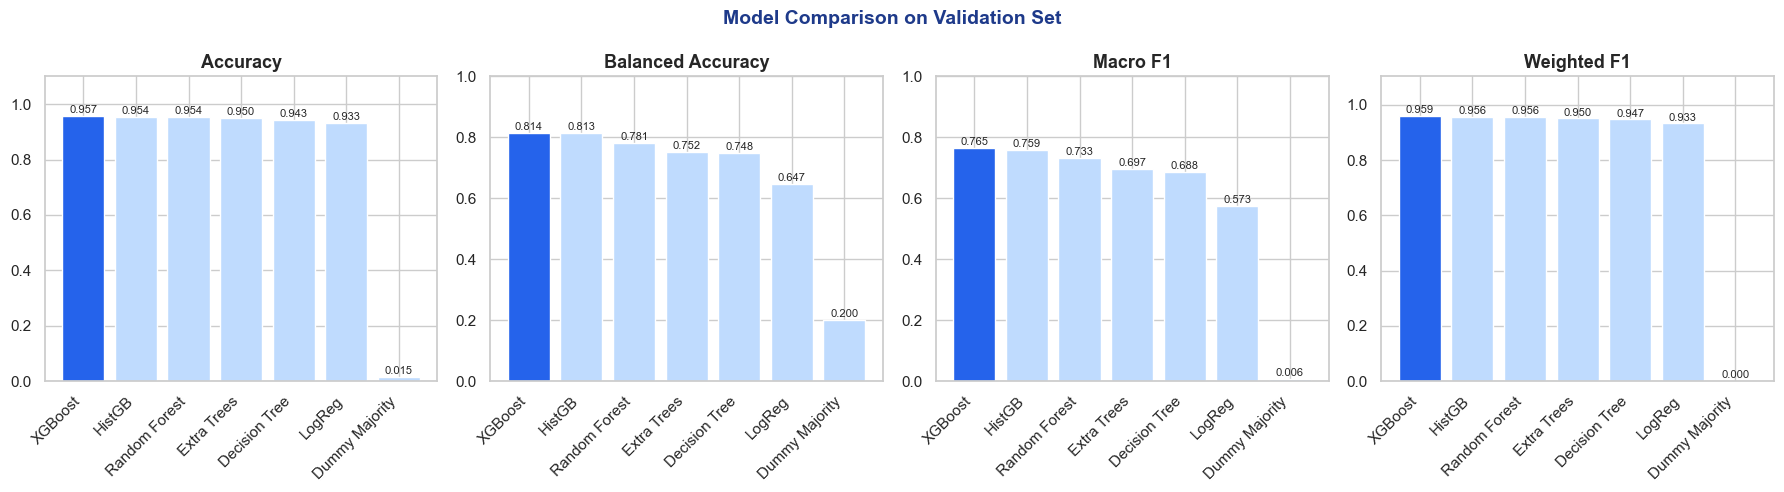

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Visual comparison on validation set
# ─────────────────────────────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"]
model_names = results_df.index.tolist()
short_names = [m.replace("Hist Gradient Boosting", "HistGB").replace("Logistic Regression", "LogReg") for m in model_names]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))
fig.suptitle("Model Comparison on Validation Set", fontsize=14, fontweight="bold", color=BLUE_D)

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df.loc[model_names, metric].values
    colors = [BLUE if i == 0 else BLUE_L for i in range(len(vals))]
    ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(short_names, rotation=45, ha="right")
    ax.set_ylim(0, max(1.0, vals.max() * 1.15))
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


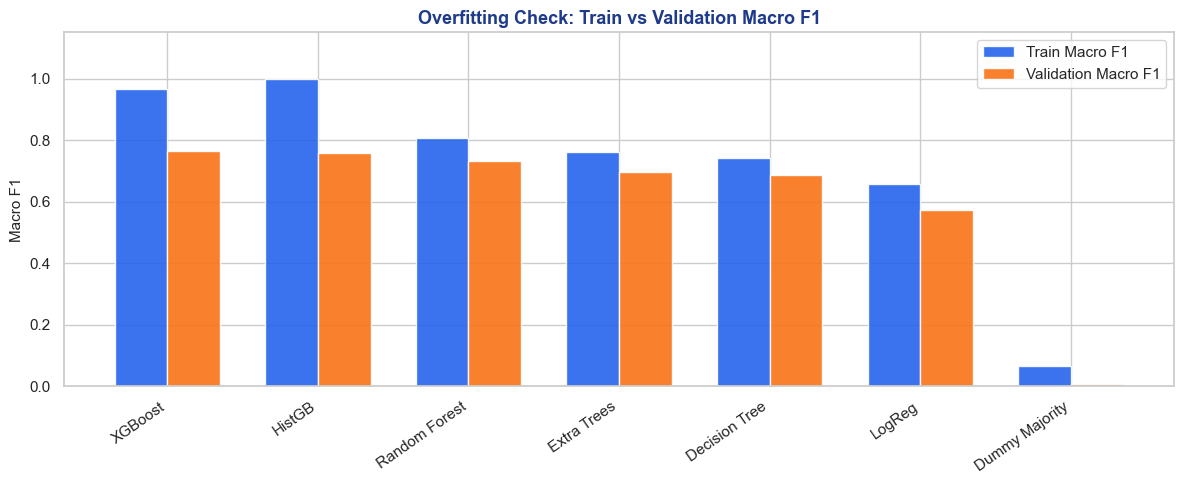

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Overfitting check: train vs validation Macro F1
# ─────────────────────────────────────────────────────────────────────────────
train_macro_f1 = []
valid_macro_f1 = []

for name in model_names:
    model = trained[name]
    y_pred_train = model.predict(X_train_fit)
    y_pred_valid = model.predict(X_valid)
    train_macro_f1.append(f1_score(y_train_fit, y_pred_train, average="macro", zero_division=0))
    valid_macro_f1.append(f1_score(y_valid, y_pred_valid, average="macro", zero_division=0))

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, train_macro_f1, width, label="Train Macro F1", color=BLUE, alpha=0.9)
ax.bar(x + width/2, valid_macro_f1, width, label="Validation Macro F1", color=ORANGE, alpha=0.9)
ax.set_title("Overfitting Check: Train vs Validation Macro F1", fontweight="bold", color=BLUE_D)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha="right")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, max(1.0, max(train_macro_f1 + valid_macro_f1) * 1.15))
ax.legend()
plt.tight_layout()
plt.show()


---

## 🔲 Section 5 — Confusion Matrices

The confusion matrix is especially useful here because the model may look good overall while still failing on rare behavior classes.


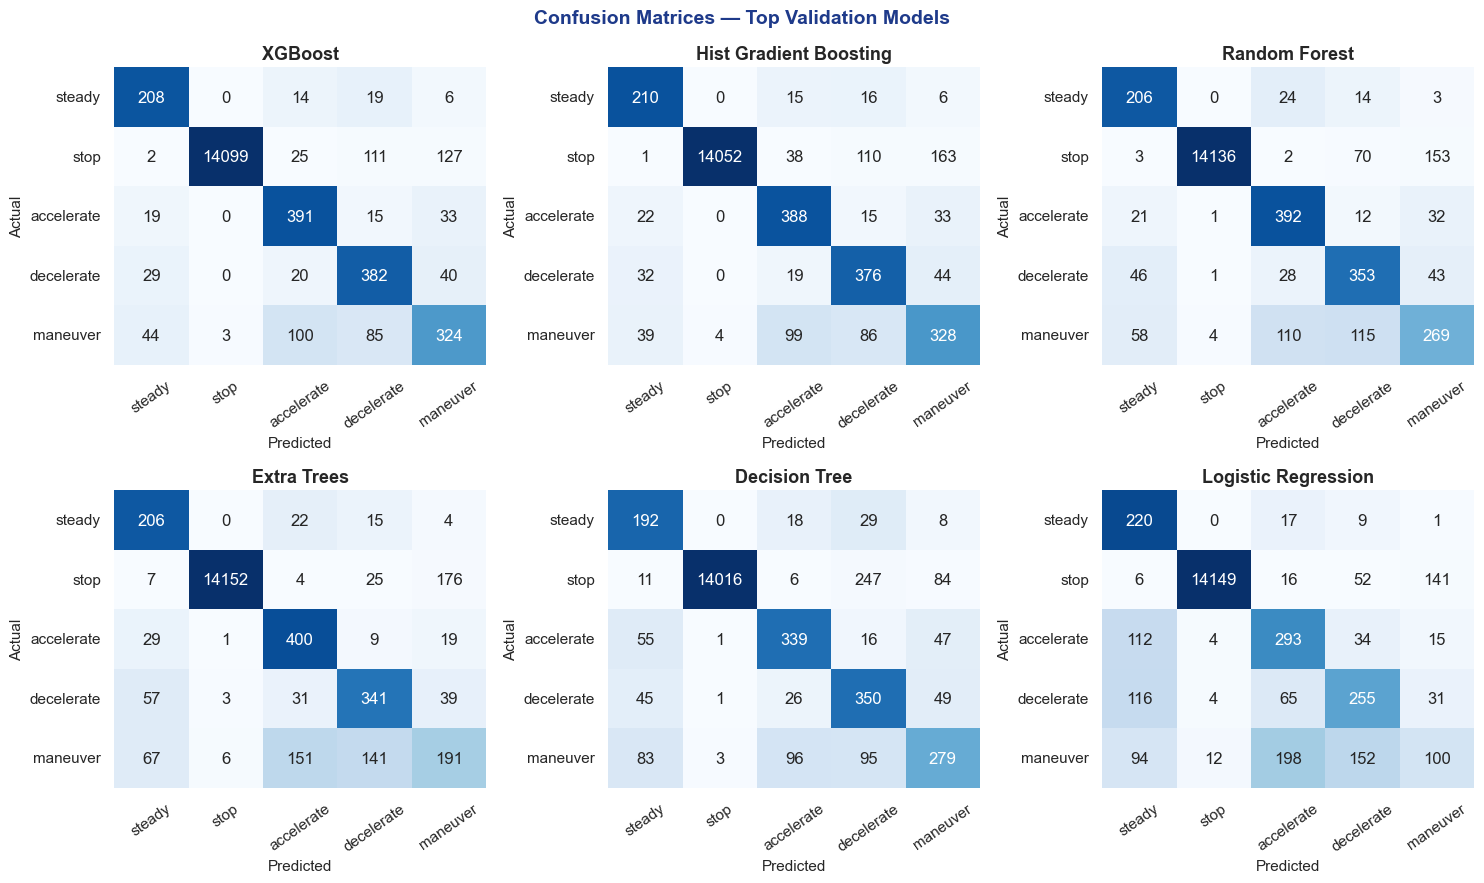

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Confusion matrices for top models
# ─────────────────────────────────────────────────────────────────────────────
top_n = min(6, len(model_names))
top_models = model_names[:top_n]

ncols = 3
nrows = int(np.ceil(top_n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.array(axes).reshape(-1)
fig.suptitle("Confusion Matrices — Top Validation Models", fontsize=14, fontweight="bold", color=BLUE_D)

for ax, name in zip(axes, top_models):
    y_pred = trained[name].predict(X_valid)
    cm = confusion_matrix(y_valid, y_pred, labels=CLASS_IDS)
    cm_norm = confusion_matrix(y_valid, y_pred, labels=CLASS_IDS, normalize="true")

    sns.heatmap(
        cm_norm,
        annot=cm,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=False,
        ax=ax,
    )
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

for ax in axes[top_n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


---

## 🏆 Section 6 — Deep Dive into the Best Validation Model

The best model is selected by **validation Macro F1**. Below we inspect per-class precision, recall, and F1.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — RAW best model validation classification report
# ─────────────────────────────────────────────────────────────────────────────
y_valid_best = best_model.predict(X_valid)
valid_report = classification_report(
    y_valid,
    y_valid_best,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(valid_report).T
print(f"Raw ML validation report — Best model: {best_name}")
display(report_df.round(4))

banner_html = f"""
<div style="background:linear-gradient(135deg,#1e3a8a,#2563eb);color:white;
     border-radius:12px;padding:1.2rem;margin:1rem 0;">
  <div style="font-size:.8rem;opacity:.85;text-transform:uppercase;letter-spacing:1px;">Raw ML model selected by Validation Macro F1</div>
  <div style="font-size:1.8rem;font-weight:700;">{best_name}</div>
  <div style="margin-top:.5rem;">Macro F1 = {results_df.loc[best_name, 'Macro F1']:.4f} &nbsp; | &nbsp;
       Balanced Accuracy = {results_df.loc[best_name, 'Balanced Accuracy']:.4f}</div>
</div>
"""
display(HTML(banner_html))


Raw ML validation report — Best model: XGBoost


,precision,recall,f1-score,support
steady,0.6887,0.8421,0.7577,247.000
stop,0.9998,0.9816,0.9906,14364.000
accelerate,0.7109,0.8537,0.7758,458.000
decelerate,0.6242,0.8110,0.7054,471.000
maneuver,0.6113,0.5827,0.5967,556.000
accuracy,0.9570,0.9570,0.9570,0.957
macro avg,0.7270,0.8142,0.7653,16096.000
weighted avg,0.9624,0.9570,0.9590,16096.000


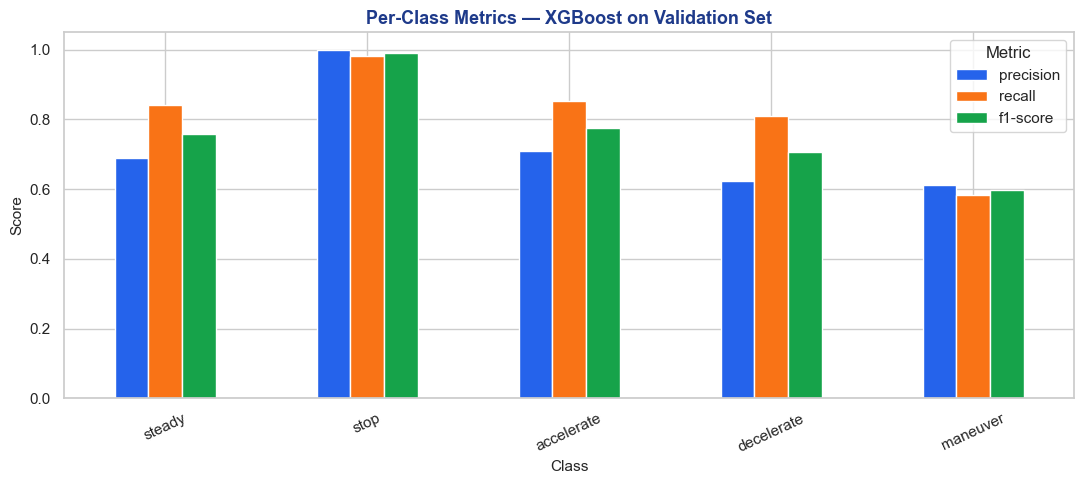

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Per-class metric chart for best model
# ─────────────────────────────────────────────────────────────────────────────
per_class = report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]].copy()

fig, ax = plt.subplots(figsize=(11, 5))
per_class.plot(kind="bar", ax=ax, color=[BLUE, ORANGE, GREEN])
ax.set_title(f"Per-Class Metrics — {best_name} on Validation Set", fontweight="bold", color=BLUE_D)
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()


---

## 🔎 Section 6A — Error Diagnostics on Validation Samples

This section inspects the specific class-level errors we care about most:

- `actual maneuver → predicted accelerate/decelerate`
- `actual steady → predicted stop/accelerate/decelerate`
- `actual decelerate → predicted maneuver`

The goal is to determine whether the error is a true model mistake, an ambiguous vessel behavior, or a noisy rule-based label.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15A — Build validation inspection dataframe for best model
# ─────────────────────────────────────────────────────────────────────────────
def build_inspect_df(model, X_eval, y_eval, df_eval, id_to_label):
    """Attach predictions, actual labels, confidence, and rule-evidence diagnostics."""
    y_pred = model.predict(X_eval)
    y_true_name = pd.Series(y_eval).map(id_to_label).reset_index(drop=True)
    y_pred_name = pd.Series(y_pred).map(id_to_label).reset_index(drop=True)

    proba = aligned_predict_proba(model, X_eval)
    pred_confidence = proba.max(axis=1) if proba is not None else np.nan

    out = df_eval.reset_index(drop=True).copy()
    out["actual_code"] = pd.Series(y_eval).reset_index(drop=True).astype(int)
    out["predicted_code"] = pd.Series(y_pred).reset_index(drop=True).astype(int)
    out["actual_class"] = y_true_name
    out["predicted_class"] = y_pred_name
    out["is_correct"] = out["actual_class"] == out["predicted_class"]
    out["pred_confidence"] = pred_confidence
    out["eval_row_id"] = np.arange(len(out))

    # If the notebook is run with an older persisted diagnostic dataframe,
    # compute rule flags here as a fallback.
    if "rule_signature" not in out.columns and "add_behavior_rule_flags" in globals():
        out = add_behavior_rule_flags(out)

    return out


def get_all_confusion_cases(inspect_df, actual_class, predicted_classes):
    """Return ALL actual→predicted error cases for aggregate diagnostics."""
    if isinstance(predicted_classes, str):
        predicted_classes = [predicted_classes]

    return inspect_df[
        (inspect_df["actual_class"] == actual_class) &
        (inspect_df["predicted_class"].isin(predicted_classes))
    ].copy()


def get_confusion_cases(
    inspect_df,
    actual_class,
    predicted_classes,
    n=20,
    sort_by_confidence=True,
    random_sample=False,
    seed=SEED,
):
    """Return a display sample of actual→predicted error cases."""
    cases_all = get_all_confusion_cases(inspect_df, actual_class, predicted_classes)
    total = len(cases_all)

    if isinstance(predicted_classes, str):
        predicted_classes = [predicted_classes]

    if total == 0:
        print(f"No cases found: actual={actual_class}, predicted={predicted_classes}")
        return cases_all

    if random_sample:
        cases = cases_all.sample(min(n, total), random_state=seed)
    elif sort_by_confidence and "pred_confidence" in cases_all.columns:
        cases = cases_all.sort_values("pred_confidence", ascending=False).head(n)
    else:
        cases = cases_all.head(n)

    print(f"Showing {len(cases)} of {total} cases: actual={actual_class}, predicted={predicted_classes}")
    return cases


def show_rule_overlap_summary(inspect_df, title="Validation"):
    """Summarize whether errors align with overlapping hand-crafted rule evidence."""
    required = {"rule_signature", "rule_overlap_count", "is_correct"}
    missing = required - set(inspect_df.columns)
    if missing:
        print(f"{title}: rule-overlap summary skipped. Missing columns: {sorted(missing)}")
        return

    print(f"\n{title} — rule signature distribution")
    display(inspect_df["rule_signature"].value_counts(dropna=False).to_frame("count"))

    print(f"\n{title} — actual class by rule signature")
    display(pd.crosstab(
        inspect_df["rule_signature"],
        inspect_df["actual_class"],
        normalize="index",
    ).round(3))

    print(f"\n{title} — predicted class by rule signature")
    display(pd.crosstab(
        inspect_df["rule_signature"],
        inspect_df["predicted_class"],
        normalize="index",
    ).round(3))

    print(f"\n{title} — error rate by rule-overlap count")
    tmp = inspect_df.copy()
    tmp["error"] = ~tmp["is_correct"]
    display(tmp.groupby("rule_overlap_count", dropna=False)["error"].agg(["count", "mean"]).round(4))

    print(f"\n{title} — error rate by rule signature")
    display(
        tmp.groupby("rule_signature", dropna=False)["error"]
           .agg(["count", "mean"])
           .sort_values("mean", ascending=False)
           .round(4)
    )


def show_targeted_error_breakdown(cases, name, source_label="ALL matching cases"):
    """Compact breakdown for one confusion direction."""
    print(f"\n{name} — targeted error breakdown ({source_label})")
    if len(cases) == 0:
        print("No cases.")
        return

    breakdown_cols = [
        "rule_signature",
        "maneuver_strength_bin",
        "speed_regime",
        "cog_reliable",
        "strong_lag_cog_jump_flag",
    ]
    for col in breakdown_cols:
        if col in cases.columns:
            print(f"\n{col}")
            display(cases[col].value_counts(dropna=False).to_frame("count"))


def summarize_targeted_error_counts(inspect_df, label="model"):
    """Return the main targeted confusion counts used in this project."""
    rows = []
    specs = [
        ("maneuver_to_accel_or_decel", "maneuver", ["accelerate", "decelerate"]),
        ("steady_to_stop_accel_decel", "steady", ["stop", "accelerate", "decelerate"]),
        ("decelerate_to_maneuver", "decelerate", ["maneuver"]),
    ]
    for error_name, actual, preds in specs:
        rows.append({
            "model_or_variant": label,
            "error_group": error_name,
            "count": len(get_all_confusion_cases(inspect_df, actual, preds)),
        })
    return pd.DataFrame(rows)


inspect_valid_df = build_inspect_df(
    model=best_model,
    X_eval=X_valid,
    y_eval=y_valid,
    df_eval=valid_df,
    id_to_label=id_to_label,
)

print("Validation inspection dataframe created:", inspect_valid_df.shape)
display(inspect_valid_df[["eval_row_id", "actual_class", "predicted_class", "is_correct", "pred_confidence"]].head())

# Overall rule-overlap diagnostics
if "rule_signature" in inspect_valid_df.columns:
    show_rule_overlap_summary(inspect_valid_df, title="Validation")

# Targeted error groups — ALL rows for aggregate diagnosis, separate sampled views for manual inspection.
maneuver_to_speed_change_all = get_all_confusion_cases(
    inspect_valid_df,
    actual_class="maneuver",
    predicted_classes=["accelerate", "decelerate"],
)
steady_to_other_all = get_all_confusion_cases(
    inspect_valid_df,
    actual_class="steady",
    predicted_classes=["stop", "accelerate", "decelerate"],
)
decelerate_to_maneuver_all = get_all_confusion_cases(
    inspect_valid_df,
    actual_class="decelerate",
    predicted_classes="maneuver",
)

maneuver_to_speed_change = get_confusion_cases(
    inspect_valid_df,
    actual_class="maneuver",
    predicted_classes=["accelerate", "decelerate"],
    n=20,
)

steady_to_other = get_confusion_cases(
    inspect_valid_df,
    actual_class="steady",
    predicted_classes=["stop", "accelerate", "decelerate"],
    n=20,
)

decelerate_to_maneuver = get_confusion_cases(
    inspect_valid_df,
    actual_class="decelerate",
    predicted_classes="maneuver",
    n=20,
)

# IMPORTANT: breakdowns below are on ALL matching rows, not just the displayed top-20 sample.
show_targeted_error_breakdown(maneuver_to_speed_change_all, "Maneuver → accelerate/decelerate", source_label="ALL")
show_targeted_error_breakdown(steady_to_other_all, "Steady → stop/accelerate/decelerate", source_label="ALL")
show_targeted_error_breakdown(decelerate_to_maneuver_all, "Decelerate → maneuver", source_label="ALL")

print("\nValidation targeted error counts")
display(summarize_targeted_error_counts(inspect_valid_df, label=best_name))

# Compact diagnostic columns: keep only columns that exist in the current prepared data.
preferred_diagnostic_cols = [
    "eval_row_id", "MMSI", "slice_start", "slice_end",
    "actual_class", "predicted_class", "pred_confidence",
    "target_class", "target_code",
    "rule_signature", "rule_overlap_count",
    "is_stop_rule", "is_accel_rule", "is_decel_rule", "is_maneuver_rule",
    "maneuver_strength_bin", "strong_lag_cog_jump_flag", "cog_reliable",
    "rep_sog", "rep_cog", "sog_mean", "sog_std", "sog_min", "sog_max",
    "n_msgs", "coverage_seconds", "cog_circular_std",
    "past_mean_rep_sog", "future_mean_rep_sog", "delta_mean_sog",
    "future_stop_ratio", "turn_change_deg_abs", "speed_regime",
    "accel_threshold_used", "decel_threshold_used",
    "rep_sog_delta_1", "rep_sog_delta_2",
    "rep_cog_diff_lag1", "rep_cog_diff_lag2",
    "rep_sog_roll2", "rep_sog_roll3",
]

diagnostic_cols = [c for c in preferred_diagnostic_cols if c in inspect_valid_df.columns]

print("\nManeuver → accelerate/decelerate — sample shown by highest confidence")
display(maneuver_to_speed_change[diagnostic_cols])

print("\nSteady → stop/accelerate/decelerate — sample shown by highest confidence")
display(steady_to_other[diagnostic_cols])

print("\nDecelerate → maneuver — sample shown by highest confidence")
display(decelerate_to_maneuver[diagnostic_cols])


Validation inspection dataframe created: (16096, 97)


,eval_row_id,actual_class,predicted_class,is_correct,pred_confidence
0,0,steady,steady,True,0.710056
1,1,decelerate,decelerate,True,0.684143
2,2,steady,decelerate,False,0.945911
3,3,maneuver,maneuver,True,0.495345
4,4,accelerate,accelerate,True,0.938421



Validation — rule signature distribution


,count
rule_signature,
STOP,14084
DECEL,476
ACCEL,462
STOP+DECEL,282
STEADY,251
DECEL+MANEUVER,240
ACCEL+MANEUVER,209
MANEUVER,92



Validation — actual class by rule signature


...

,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
4018,4018,366677000,2024-01-28 14:00:00,2024-01-28 14:10:00,maneuver,decelerate,0.991533,maneuver,4,DECEL+MANEUVER,...,47.223269,mid,1.0,1.0,-3.60,0.00,6.813424,8.667647,7.500,8.100000
5675,5675,366987890,2024-01-05 04:20:00,2024-01-05 04:30:00,maneuver,accelerate,0.972697,maneuver,4,ACCEL+MANEUVER,...,66.558897,mid,1.0,1.0,0.40,0.55,-25.941746,48.423849,5.400,5.150000
3952,3952,366518000,2024-01-13 04:30:00,2024-01-13 04:40:00,maneuver,decelerate,0.969825,maneuver,4,DECEL+MANEUVER,...,45.529913,mid,1.0,1.0,-2.00,-1.30,13.788873,14.307693,6.300,7.066667
13613,13613,367789310,2024-01-01 01:10:00,2024-01-01 01:20:00,maneuver,accelerate,0.964014,maneuver,4,ACCEL+MANEUVER,...,47.717962,mid,1.0,1.0,0.90,0.15,-4.245589,-28.630664,5.850,5.650000
13137,13137,367691280,2024-01-28 10:40:00,2024-01-28 10:50:00,maneuver,decelerate,0.960570,maneuver,4,DECEL+MANEUVER,...,48.694373,mid,1.0,1.0,-0.40,-1.65,23.798886,5.120084,5.000,5.616667
13753,13753,367789310,2024-01-20 05:50:00,2024-01-20 06:00:00,maneuver,accelerate,0.944302,maneuver,4,ACCEL+MANEUVER,...,54.002575,mid,1.0,1.0,0.85,1.20,-5.826541,-26.276555,7.025,6.483333
6637,6637,367175740,2024-01-29 19:10:00,2024-01-29 19:20:00,maneuver,accelerate,0.942982,maneuver,4,ACCEL+MANEUVER,...,45.544800,mid,1.0,1.0,1.10,-2.60,10.687610,143.672077,5.150,5.833333
13810,13810,368021936,2024-01-04 21:00:00,2024-01-04 21:10:00,maneuver,decelerate,0.942542,maneuver,4,DECEL+MANEUVER,...,99.438094,high,1.5,1.5,-6.00,-1.10,12.532509,-178.520369,12.900,14.266667
12836,12836,367645120,2024-01-05 00:10:00,2024-01-05 00:20:00,maneuver,accelerate,0.941294,maneuver,4,ACCEL+MANEUVER,...,80.667544,mid,1.0,1.0,0.70,-0.40,-1.087078,-34.474719,5.550,5.566667
361,361,338363000,2024-01-25 17:10:00,2024-01-25 17:20:00,maneuver,decelerate,0.939547,maneuver,4,DECEL+MANEUVER,...,48.173708,mid,1.0,1.0,-2.50,-0.20,19.696044,15.003956,6.050,6.533333



Steady → stop/accelerate/decelerate — sample shown by highest confidence


,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
15346,15346,368315660,2024-01-23 23:30:00,2024-01-23 23:40:00,steady,decelerate,0.958194,steady,0,STEADY,...,9.478073,mid,1.0,1.0,0.90,0.30,178.013926,-6.098073,9.850,9.600000
2,2,259795000,2024-01-04 12:00:00,2024-01-04 12:10:00,steady,decelerate,0.945911,steady,0,STEADY,...,7.143954,mid,1.0,1.0,-0.90,-0.40,10.132579,29.730323,5.850,6.133333
12939,12939,367663150,2024-01-14 08:00:00,2024-01-14 08:10:00,steady,accelerate,0.941329,steady,0,STEADY,...,17.676010,mid,1.0,1.0,0.10,0.45,-35.891700,-144.150257,5.450,5.283333
12834,12834,367645120,2024-01-04 23:50:00,2024-01-05 00:00:00,steady,accelerate,0.913628,steady,0,STEADY,...,29.623304,mid,1.0,1.0,0.05,-1.05,-177.391523,23.921473,5.575,5.916667
12712,12712,367635140,2024-01-19 23:50:00,2024-01-20 00:00:00,steady,decelerate,0.892254,steady,0,STEADY,...,23.234936,mid,1.0,1.0,-0.30,-0.80,15.253273,8.775592,5.750,6.066667
483,483,338628000,2024-01-20 03:30:00,2024-01-20 03:40:00,steady,decelerate,0.885823,steady,0,STEADY,...,20.924821,mid,1.0,1.0,0.45,1.15,178.572397,-10.669005,7.975,7.516667
15425,15425,368324450,2024-01-19 12:50:00,2024-01-19 13:00:00,steady,accelerate,0.881650,steady,0,STEADY,...,14.061140,mid,1.0,1.0,5.70,0.00,132.610832,0.000000,2.850,1.900000
12835,12835,367645120,2024-01-05 00:00:00,2024-01-05 00:10:00,steady,accelerate,0.878086,steady,0,STEADY,...,26.667214,mid,1.0,1.0,-0.40,0.05,-34.474719,-177.391523,5.400,5.450000
4989,4989,366981940,2024-01-04 20:00:00,2024-01-04 20:10:00,steady,accelerate,0.877948,steady,0,STEADY,...,9.050523,mid,1.0,1.0,0.00,-0.10,-29.072420,-179.085979,7.200,7.233333
169,169,259795000,2024-01-20 18:10:00,2024-01-20 18:20:00,steady,decelerate,0.804823,steady,0,STEADY,...,32.031206,mid,1.0,1.0,-0.20,-0.10,20.850200,5.344692,5.800,5.866667



Decelerate → maneuver — sample shown by highest confidence


,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
5009,5009,366987890,2023-12-31 10:00:00,2023-12-31 10:10:00,decelerate,maneuver,0.957430,decelerate,3,DECEL,...,32.714506,mid,1.0,1.0,0.20,1.10,-13.101919,18.497787,5.700,5.300000
6709,6709,367304000,2024-01-05 13:40:00,2024-01-05 13:50:00,decelerate,maneuver,0.848690,decelerate,3,DECEL,...,NaN,mid,1.0,1.0,1.30,0.00,162.859098,0.000000,0.650,0.433333
14956,14956,368225760,2024-01-15 14:20:00,2024-01-15 14:30:00,decelerate,maneuver,0.824213,decelerate,3,DECEL,...,24.277543,high,1.5,1.5,3.30,0.10,177.099617,-6.319734,16.550,15.966667
6734,6734,367304000,2024-01-19 02:30:00,2024-01-19 02:40:00,decelerate,maneuver,0.820405,decelerate,3,DECEL,...,34.180435,high,1.5,1.5,-3.90,-1.40,-17.954285,18.051989,7.350,8.466667
15374,15374,368315660,2024-01-28 01:40:00,2024-01-28 01:50:00,decelerate,maneuver,0.815720,decelerate,3,DECEL,...,41.225324,mid,1.0,1.0,-0.05,-3.50,-11.168245,15.230020,5.725,6.900000
14928,14928,368225760,2024-01-01 20:20:00,2024-01-01 20:30:00,decelerate,maneuver,0.809097,decelerate,3,DECEL,...,42.825181,high,1.5,1.5,1.10,9.60,157.583120,-51.916770,18.550,15.166667
12562,12562,367622850,2024-01-02 21:50:00,2024-01-02 22:00:00,decelerate,maneuver,0.806671,decelerate,3,DECEL,...,NaN,mid,1.0,1.0,NaN,NaN,NaN,NaN,3.000,3.000000
5953,5953,366987890,2024-01-12 09:20:00,2024-01-12 09:30:00,decelerate,maneuver,0.757621,decelerate,3,DECEL,...,39.302344,mid,1.0,1.0,0.00,-0.20,7.569836,17.726047,4.100,4.166667
4494,4494,366874650,2024-01-19 00:10:00,2024-01-19 00:20:00,decelerate,maneuver,0.725589,decelerate,3,DECEL,...,NaN,mid,1.0,1.0,-6.65,0.70,-92.688512,-8.412019,12.425,13.300000
13683,13683,367789310,2024-01-16 00:50:00,2024-01-16 01:00:00,decelerate,maneuver,0.719802,decelerate,3,DECEL,...,NaN,mid,1.0,1.0,-3.25,-1.10,102.805093,-7.266218,3.575,4.483333


---

## 🧪 Section 6B — Diagnostic Rule-Priority and Guard Experiments

These cells test follow-up hypotheses from the diagnostics:

1. **Conservative priority-aware post-processing:**
   - `ACCEL+MANEUVER` / `DECEL+MANEUVER` → force prediction to `maneuver`.
   - `STOP+DECEL` → force prediction to `stop`.
   - `STOP+ACCEL` is **not** forced to stop in the conservative version because it is rare/ambiguous in the held-out data.
2. **Targeted guard experiments:** evaluate whether narrow corrections improve the remaining maneuver/steady and decelerate/maneuver boundary errors.
3. **COG-lag feature conflict:** train one additional model after removing `rep_cog_diff_lag1` and `rep_cog_diff_lag2`, optionally replacing them with the cleaner `strong_lag_cog_jump_flag` diagnostic flag.

Treat these priority/guard variants as **hybrid rule + ML diagnostic experiments**. For a strict future-prediction submission, do not use a post-processing rule that depends on target-construction diagnostics derived from future slices. The raw ML model is the clean predictive baseline.


Comment clarification: the steady guard is based on persisted stability features, but the maneuver/deceleration guard variants use diagnostic rule-signature/turn evidence. Therefore, they are kept as diagnostic experiments and are not selected as the final strict ML model.


---

### Important reporting note

The report printed in **Section 6 — raw best-model validation report** is intentionally the **raw ML validation report**. It does **not** include rule-priority post-processing.

That raw report is computed from:

```python
best_model.predict(X_valid)
```

The recommended diagnostic rule-assisted result is printed later in **Section 6B — Rule-Priority and COG-Lag Experiments**, in the cell titled:

```text
CELL 15C — Priority-aware post-processing and COG-lag ablation experiment
```

Look for the output labeled:

```text
Recommended hybrid validation report:
<best model name> + recommended conservative priority
```

So if the raw report is similar to an earlier run, that is not an error. The priority-aware version changes the **post-processed prediction vector**, not the underlying trained estimator.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15C — Priority-aware post-processing, steady guard, and COG-lag ablation
# ─────────────────────────────────────────────────────────────────────────────
def metrics_from_predictions(y_true, y_pred, label):
    """Compute the same core metrics for an already-generated prediction vector."""
    return {
        "Variant": label,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


# Conservative steady guard settings.
# Purpose: improve steady precision/recall without overriding high-confidence model predictions.
STEADY_GUARD_CONFIDENCE_MAX = 0.60
STEADY_GUARD_APPLY_TO = ["accelerate", "decelerate"]


def apply_steady_guard(y_pp, inspect_df, confidence_max=STEADY_GUARD_CONFIDENCE_MAX):
    """
    Inference-safe steady correction based on past/current stability features.

    If the prepared data says the row is a moving-steady candidate and the model
    predicts accelerate/decelerate with only moderate confidence, switch to steady.

    This uses `is_moving_steady_candidate`, which is built in preprocessing from
    current/past SOG and COG stability features only.
    """
    if "is_moving_steady_candidate" not in inspect_df.columns:
        return y_pp.astype(int).copy()

    steady_code = label_to_id.get("steady")
    if steady_code is None:
        return y_pp.astype(int).copy()

    y_out = pd.Series(y_pp).reset_index(drop=True).astype(int).copy()
    pred_names = y_out.map(id_to_label)

    conf = pd.to_numeric(inspect_df.get("pred_confidence", pd.Series(np.nan, index=inspect_df.index)), errors="coerce")
    steady_candidate = pd.to_numeric(inspect_df["is_moving_steady_candidate"], errors="coerce").fillna(0).astype(int).eq(1)

    # Extra conservative guard for this moderate-label experiment:
    # only correct accel/decel to steady when the rule signature itself is exactly
    # STEADY and there is no strong lagged COG jump. This keeps steady from
    # becoming a broad fallback during post-processing.
    rule_is_moderate_steady = (
        inspect_df.get("rule_signature", pd.Series("", index=inspect_df.index))
        .astype(str)
        .reset_index(drop=True)
        .eq("STEADY")
    )
    no_strong_cog_jump = (
        pd.to_numeric(
            inspect_df.get("strong_lag_cog_jump_flag", pd.Series(0, index=inspect_df.index)),
            errors="coerce",
        )
        .fillna(0)
        .astype(int)
        .reset_index(drop=True)
        .eq(0)
    )

    correction_mask = (
        steady_candidate.reset_index(drop=True) &
        rule_is_moderate_steady &
        no_strong_cog_jump &
        pred_names.isin(STEADY_GUARD_APPLY_TO) &
        (conf.reset_index(drop=True).fillna(1.0) <= confidence_max)
    )

    y_out.loc[correction_mask] = steady_code
    return y_out.astype(int)



# Narrow maneuver→steady guard settings.
# Purpose: reduce false steady predictions on rows that have clear maneuver evidence,
# without undoing the moderate steady-label improvement.
MANEUVER_GUARD_MIN_TURN_DEG = 60.0
MANEUVER_GUARD_EXTREME_TURN_DEG = 90.0
MANEUVER_GUARD_CONFIDENCE_MAX = 0.75


def apply_maneuver_steady_guard(y_pp, inspect_df):
    """
    Diagnostic guard for the remaining MANEUVER → steady failure mode.

    Only correct steady predictions to maneuver when:
      1. the post-processed prediction is currently steady,
      2. the diagnostic rule signature is exactly MANEUVER,
      3. heading-change evidence is strong enough, and
      4. the model is not extremely confident in steady, unless the turn is extreme.

    This is intentionally narrower than forcing every MANEUVER signature row to maneuver.
    It targets the specific observed error: maneuver-like rows being absorbed by steady.

    Important: this guard uses diagnostic rule-signature/turn evidence, so it is not
    promoted to the final strict predictive ML result in this notebook.
    """
    steady_code = label_to_id.get("steady")
    maneuver_code = label_to_id.get("maneuver")
    if steady_code is None or maneuver_code is None:
        return pd.Series(y_pp).reset_index(drop=True).astype(int).copy()

    y_out = pd.Series(y_pp).reset_index(drop=True).astype(int).copy()
    sig = (
        inspect_df.get("rule_signature", pd.Series("", index=inspect_df.index))
        .astype(str)
        .reset_index(drop=True)
    )

    turn = pd.to_numeric(
        inspect_df.get("turn_change_deg_abs", pd.Series(np.nan, index=inspect_df.index)),
        errors="coerce",
    ).reset_index(drop=True)

    strong_lag_cog_jump = pd.to_numeric(
        inspect_df.get("strong_lag_cog_jump_flag", pd.Series(0, index=inspect_df.index)),
        errors="coerce",
    ).fillna(0).astype(int).reset_index(drop=True).eq(1)

    conf = pd.to_numeric(
        inspect_df.get("pred_confidence", pd.Series(np.nan, index=inspect_df.index)),
        errors="coerce",
    ).reset_index(drop=True)

    strong_heading_evidence = (turn >= MANEUVER_GUARD_MIN_TURN_DEG) | strong_lag_cog_jump
    extreme_turn = turn >= MANEUVER_GUARD_EXTREME_TURN_DEG
    confidence_allows_override = conf.fillna(1.0).le(MANEUVER_GUARD_CONFIDENCE_MAX) | extreme_turn

    correction_mask = (
        y_out.eq(steady_code) &
        sig.eq("MANEUVER") &
        strong_heading_evidence &
        confidence_allows_override
    )

    y_out.loc[correction_mask] = maneuver_code
    return y_out.astype(int)



# Narrow deceleration→maneuver guard settings.
# Purpose: reduce DECEL rows that are still predicted as maneuver when the
# heading-change evidence is weak and the raw model is not extremely confident.
DECEL_GUARD_MAX_TURN_DEG = 40.0
DECEL_GUARD_CONFIDENCE_MAX = 0.75


def apply_deceleration_maneuver_guard(y_pp, inspect_df):
    """
    Diagnostic guard for the remaining DECEL → maneuver failure mode.

    Only correct maneuver predictions to decelerate when:
      1. the post-processed prediction is currently maneuver,
      2. the diagnostic rule signature is exactly DECEL,
      3. heading-change evidence is weak enough, and
      4. the model is not extremely confident in maneuver.

    This deliberately does not touch DECEL+MANEUVER overlap rows, because those
    were intentionally prioritized as maneuver in the conservative rule priority.

    Important: this guard uses diagnostic rule-signature/turn evidence, so it is not
    promoted to the final strict predictive ML result in this notebook.
    """
    maneuver_code = label_to_id.get("maneuver")
    decel_code = label_to_id.get("decelerate")
    if maneuver_code is None or decel_code is None:
        return pd.Series(y_pp).reset_index(drop=True).astype(int).copy()

    y_out = pd.Series(y_pp).reset_index(drop=True).astype(int).copy()
    sig = (
        inspect_df.get("rule_signature", pd.Series("", index=inspect_df.index))
        .astype(str)
        .reset_index(drop=True)
    )

    turn = pd.to_numeric(
        inspect_df.get("turn_change_deg_abs", pd.Series(np.nan, index=inspect_df.index)),
        errors="coerce",
    ).reset_index(drop=True)

    strong_lag_cog_jump = pd.to_numeric(
        inspect_df.get("strong_lag_cog_jump_flag", pd.Series(0, index=inspect_df.index)),
        errors="coerce",
    ).fillna(0).astype(int).reset_index(drop=True).eq(1)

    conf = pd.to_numeric(
        inspect_df.get("pred_confidence", pd.Series(np.nan, index=inspect_df.index)),
        errors="coerce",
    ).reset_index(drop=True)

    weak_heading_evidence = turn.fillna(999.0).le(DECEL_GUARD_MAX_TURN_DEG) & (~strong_lag_cog_jump)
    confidence_allows_override = conf.fillna(1.0).le(DECEL_GUARD_CONFIDENCE_MAX)

    correction_mask = (
        y_out.eq(maneuver_code) &
        sig.eq("DECEL") &
        weak_heading_evidence &
        confidence_allows_override
    )

    y_out.loc[correction_mask] = decel_code
    return y_out.astype(int)

def apply_priority_postprocessing(inspect_df, mode="recommended_conservative"):
    """
    Apply rule-priority corrections to predictions.

    Modes:
    - none/raw: no correction.
    - maneuver_only:
        ACCEL+MANEUVER / DECEL+MANEUVER -> maneuver.
    - recommended_conservative:
        ACCEL+MANEUVER / DECEL+MANEUVER -> maneuver,
        STOP+DECEL -> stop,
        but DO NOT force STOP+ACCEL -> stop because that group can include steady.
    - recommended_conservative_with_steady_guard:
        recommended_conservative + a confidence-limited steady correction for
        `is_moving_steady_candidate` rows predicted as accelerate/decelerate.
    - recommended_conservative_with_maneuver_guard:
        recommended_conservative + a narrow correction from steady back to maneuver
        for exact MANEUVER rule-signature rows with strong heading-change evidence.
    - recommended_conservative_with_maneuver_decel_guard:
        recommended_conservative_with_maneuver_guard + a narrow correction from
        maneuver back to decelerate for exact DECEL rows with weak heading evidence.
    - maneuver_and_all_stop_overlap:
        ACCEL+MANEUVER / DECEL+MANEUVER -> maneuver,
        STOP+ACCEL / STOP+DECEL -> stop. More aggressive.
    """
    if mode in [None, "none", "raw"]:
        return inspect_df["predicted_code"].astype(int).copy()

    if "rule_signature" not in inspect_df.columns:
        raise ValueError("rule_signature column is required for priority post-processing.")

    y_pp = inspect_df["predicted_code"].astype(int).copy()
    sig = inspect_df["rule_signature"].astype(str)

    maneuver_code = label_to_id.get("maneuver")
    stop_code = label_to_id.get("stop")

    maneuver_modes = [
        "maneuver_only",
        "recommended_conservative",
        "recommended_conservative_with_steady_guard",
        "recommended_conservative_with_maneuver_guard",
        "recommended_conservative_with_maneuver_decel_guard",
        "maneuver_and_all_stop_overlap",
    ]

    if maneuver_code is not None and mode in maneuver_modes:
        maneuver_overlap = sig.isin(["ACCEL+MANEUVER", "DECEL+MANEUVER"])
        y_pp.loc[maneuver_overlap] = maneuver_code

    if stop_code is not None and mode in ["recommended_conservative", "recommended_conservative_with_steady_guard", "recommended_conservative_with_maneuver_guard", "recommended_conservative_with_maneuver_decel_guard"]:
        # Conservative: STOP+DECEL was almost always actual stop and had the highest error rate.
        # We intentionally do not force STOP+ACCEL because that group can include actual steady rows.
        y_pp.loc[sig.eq("STOP+DECEL")] = stop_code

    if stop_code is not None and mode == "maneuver_and_all_stop_overlap":
        stop_overlap = sig.isin(["STOP+ACCEL", "STOP+DECEL"])
        y_pp.loc[stop_overlap] = stop_code

    if mode == "recommended_conservative_with_steady_guard":
        y_pp = apply_steady_guard(y_pp, inspect_df)

    if mode in ["recommended_conservative_with_maneuver_guard", "recommended_conservative_with_maneuver_decel_guard"]:
        y_pp = apply_maneuver_steady_guard(y_pp, inspect_df)

    if mode == "recommended_conservative_with_maneuver_decel_guard":
        y_pp = apply_deceleration_maneuver_guard(y_pp, inspect_df)

    return y_pp.astype(int)


def inspect_with_replaced_predictions(base_inspect_df, y_pred_codes, variant_label):
    """Copy an inspection dataframe but replace predictions with a post-processed vector."""
    out = base_inspect_df.copy()
    out["predicted_code"] = pd.Series(y_pred_codes).reset_index(drop=True).astype(int)
    out["predicted_class"] = out["predicted_code"].map(id_to_label)
    out["is_correct"] = out["actual_class"] == out["predicted_class"]
    out["variant"] = variant_label
    return out


def class_f1_table(y_true, predictions_by_label):
    """Compact per-class F1 comparison across prediction variants."""
    rows = []
    for label, y_pred in predictions_by_label.items():
        report = classification_report(
            y_true,
            y_pred,
            labels=CLASS_IDS,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
        for class_name in CLASS_NAMES:
            rows.append({
                "Variant": label,
                "class": class_name,
                "precision": report[class_name]["precision"],
                "recall": report[class_name]["recall"],
                "f1": report[class_name]["f1-score"],
                "support": report[class_name]["support"],
            })
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# Priority-aware + steady-guard variants on validation.
# ─────────────────────────────────────────────────────────────────────────────
priority_variants = {
    f"{best_name} raw": "raw",
    f"{best_name} + maneuver-priority": "maneuver_only",
    f"{best_name} + recommended conservative priority": "recommended_conservative",
    f"{best_name} + recommended conservative priority + steady guard": "recommended_conservative_with_steady_guard",
    f"{best_name} + recommended conservative priority + maneuver→steady guard": "recommended_conservative_with_maneuver_guard",
    f"{best_name} + recommended conservative priority + maneuver/decel guard": "recommended_conservative_with_maneuver_decel_guard",
    f"{best_name} + aggressive maneuver/all-stop priority": "maneuver_and_all_stop_overlap",
}

priority_rows = []
priority_inspect_dfs = {}
priority_predictions = {}

for label, mode in priority_variants.items():
    y_variant = apply_priority_postprocessing(inspect_valid_df, mode=mode)
    priority_predictions[label] = y_variant
    priority_rows.append(metrics_from_predictions(y_valid, y_variant, label))
    priority_inspect_dfs[label] = inspect_with_replaced_predictions(inspect_valid_df, y_variant, label)

priority_results_df = pd.DataFrame(priority_rows).set_index("Variant").sort_values("Macro F1", ascending=False)
print("Validation metrics after priority-aware post-processing and steady guard")
display(priority_results_df.round(4))

print("\nPer-class validation F1 comparison")
priority_class_f1_df = class_f1_table(y_valid, priority_predictions)
display(priority_class_f1_df.pivot(index="class", columns="Variant", values="f1").round(4))

# Explicit validation classification report for the recommended steady-F1 variant.
steady_guard_label = f"{best_name} + recommended conservative priority + steady guard"
y_valid_steady_guard = priority_predictions[steady_guard_label]
steady_guard_report = classification_report(
    y_valid,
    y_valid_steady_guard,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
steady_guard_report_df = pd.DataFrame(steady_guard_report).T
print(f"\nRecommended steady-F1 validation report: {steady_guard_label}")
display(steady_guard_report_df.round(4))


# Explicit validation classification report for the targeted maneuver→steady correction variant.
maneuver_guard_label = f"{best_name} + recommended conservative priority + maneuver→steady guard"
y_valid_maneuver_guard = priority_predictions[maneuver_guard_label]
maneuver_guard_report = classification_report(
    y_valid,
    y_valid_maneuver_guard,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
maneuver_guard_report_df = pd.DataFrame(maneuver_guard_report).T
print(f"\nTargeted maneuver→steady guard validation report: {maneuver_guard_label}")
display(maneuver_guard_report_df.round(4))

# Explicit validation classification report for the combined maneuver/deceleration guard variant.
maneuver_decel_guard_label = f"{best_name} + recommended conservative priority + maneuver/decel guard"
y_valid_maneuver_decel_guard = priority_predictions[maneuver_decel_guard_label]
maneuver_decel_guard_report = classification_report(
    y_valid,
    y_valid_maneuver_decel_guard,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
maneuver_decel_guard_report_df = pd.DataFrame(maneuver_decel_guard_report).T
print(f"\nTargeted maneuver/decel guard validation report: {maneuver_decel_guard_label}")
display(maneuver_decel_guard_report_df.round(4))

# Keep the previous recommended conservative report too, for direct comparison.
recommended_priority_label = f"{best_name} + recommended conservative priority"
y_valid_recommended_priority = priority_predictions[recommended_priority_label]
recommended_priority_report = classification_report(
    y_valid,
    y_valid_recommended_priority,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
recommended_priority_report_df = pd.DataFrame(recommended_priority_report).T
print(f"\nRecommended hybrid validation report: {recommended_priority_label}")
display(recommended_priority_report_df.round(4))

print("\nTargeted validation error counts after priority-aware post-processing")
priority_error_counts = pd.concat([
    summarize_targeted_error_counts(df, label=label)
    for label, df in priority_inspect_dfs.items()
], ignore_index=True)
display(priority_error_counts.pivot(index="error_group", columns="model_or_variant", values="count"))

# Extra focus: steady errors only.
def summarize_steady_errors(inspect_df, label):
    return {
        "model_or_variant": label,
        "actual_steady_pred_stop_accel_decel": len(get_all_confusion_cases(inspect_df, "steady", ["stop", "accelerate", "decelerate"])),
        "actual_steady_pred_accel_decel": len(get_all_confusion_cases(inspect_df, "steady", ["accelerate", "decelerate"])),
        "nonsteady_pred_steady": int(((inspect_df["actual_class"] != "steady") & (inspect_df["predicted_class"] == "steady")).sum()),
    }

steady_error_summary_df = pd.DataFrame([
    summarize_steady_errors(df, label)
    for label, df in priority_inspect_dfs.items()
])
print("\nSteady-specific validation error summary")
display(steady_error_summary_df)

# Recommended diagnostic focus: compare raw vs conservative+steady guard by rule signature.
inspect_valid_steady_guard = priority_inspect_dfs[steady_guard_label]
print("\nRecommended conservative priority + steady guard — validation rule-overlap summary")
show_rule_overlap_summary(inspect_valid_steady_guard, title="Validation recommended conservative priority + steady guard")

inspect_valid_maneuver_guard = priority_inspect_dfs[maneuver_guard_label]
print("\nRecommended conservative priority + maneuver→steady guard — validation rule-overlap summary")
show_rule_overlap_summary(inspect_valid_maneuver_guard, title="Validation recommended conservative priority + maneuver→steady guard")

inspect_valid_maneuver_decel_guard = priority_inspect_dfs[maneuver_decel_guard_label]
print("\nRecommended conservative priority + maneuver/decel guard — validation rule-overlap summary")
show_rule_overlap_summary(inspect_valid_maneuver_decel_guard, title="Validation recommended conservative priority + maneuver/decel guard")




# Moderate-label + maneuver/decel-guard diagnostics: compare produced class distribution with original baseline if available.
BASELINE_BALANCED_DIR = Path("prepared_ds2_diagnosable_csv/balanced_train")

def _load_baseline_y(split_name):
    path = BASELINE_BALANCED_DIR / f"y_{split_name}.csv"
    if path.exists():
        return pd.read_csv(path)["target_code"].astype(int)
    return None

baseline_distribution_rows = []
for split_name, y_current in [("train", y_train), ("valid", y_valid), ("test", y_test)]:
    current_counts = pd.Series(y_current).map(id_to_label).value_counts(normalize=True)
    for cls in CLASS_NAMES:
        baseline_distribution_rows.append({
            "source": "moderate_current",
            "split": split_name,
            "class": cls,
            "proportion": float(current_counts.get(cls, 0.0)),
        })

    y_baseline = _load_baseline_y(split_name)
    if y_baseline is not None:
        baseline_counts = y_baseline.map(id_to_label).value_counts(normalize=True)
        for cls in CLASS_NAMES:
            baseline_distribution_rows.append({
                "source": "baseline_if_present",
                "split": split_name,
                "class": cls,
                "proportion": float(baseline_counts.get(cls, 0.0)),
            })

moderate_vs_baseline_distribution_df = pd.DataFrame(baseline_distribution_rows)
print("\nModerate-label + maneuver/decel-guard class distribution check")
display(moderate_vs_baseline_distribution_df.pivot_table(
    index=["split", "class"],
    columns="source",
    values="proportion",
    aggfunc="first",
).round(4))


# ─────────────────────────────────────────────────────────────────────────────
# COG-lag ablation: train the same selected model family without lag COG diffs.
# ─────────────────────────────────────────────────────────────────────────────
RUN_COG_LAG_ABLATION = True
DROP_COG_LAG_FEATURES = ["rep_cog_diff_lag1", "rep_cog_diff_lag2", "maneuver_intensity_score"]
ADD_STRONG_LAG_COG_FLAG_IN_ABLATION = True


def build_cog_ablation_matrix(X, df, base_feature_cols):
    """Drop raw lagged COG-difference features and dependent maneuver-intensity feature, then optionally add a cleaner flag."""
    cols = [c for c in base_feature_cols if c not in DROP_COG_LAG_FEATURES]
    X_out = X[cols].copy()

    if ADD_STRONG_LAG_COG_FLAG_IN_ABLATION and "strong_lag_cog_jump_flag" in df.columns:
        X_out["strong_lag_cog_jump_flag"] = df["strong_lag_cog_jump_flag"].fillna(False).astype(int).values

    return X_out


if RUN_COG_LAG_ABLATION:
    removed = [c for c in DROP_COG_LAG_FEATURES if c in feature_cols]
    print("COG-lag ablation — removed features:", removed if removed else "None found")
    print("COG-lag ablation — add strong_lag_cog_jump_flag:", ADD_STRONG_LAG_COG_FLAG_IN_ABLATION)

    X_train_cog_ablation = build_cog_ablation_matrix(X_train, train_df, feature_cols)
    X_valid_cog_ablation = build_cog_ablation_matrix(X_valid, valid_df, feature_cols)

    cog_ablation_model = clone(best_model)

    start = time.time()
    if best_name == "XGBoost":
        full_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        cog_ablation_model.fit(X_train_cog_ablation, y_train, sample_weight=full_sample_weight)
    else:
        try:
            full_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
            cog_ablation_model.fit(X_train_cog_ablation, y_train, sample_weight=full_sample_weight)
        except TypeError:
            cog_ablation_model.fit(X_train_cog_ablation, y_train)

    cog_ablation_fit_time = time.time() - start
    cog_ablation_metrics = evaluate_model(cog_ablation_model, X_valid_cog_ablation, y_valid)
    cog_ablation_metrics["Variant"] = f"{best_name} without raw lag COG diffs"
    cog_ablation_metrics["Fit Time Sec"] = cog_ablation_fit_time

    ablation_compare_df = pd.DataFrame([
        {"Variant": f"{best_name} raw", **evaluate_model(best_model, X_valid, y_valid), "Fit Time Sec": fit_times.get(best_name, np.nan)},
        cog_ablation_metrics,
    ]).set_index("Variant").sort_values("Macro F1", ascending=False)

    print("\nValidation comparison: baseline vs COG-lag ablation")
    display(ablation_compare_df.round(4))

    inspect_valid_cog_ablation = build_inspect_df(
        model=cog_ablation_model,
        X_eval=X_valid_cog_ablation,
        y_eval=y_valid,
        df_eval=valid_df,
        id_to_label=id_to_label,
    )

    print("\nTargeted validation error counts: baseline vs COG-lag ablation")
    ablation_error_counts = pd.concat([
        summarize_targeted_error_counts(inspect_valid_df, label=f"{best_name} raw"),
        summarize_targeted_error_counts(inspect_valid_cog_ablation, label="COG-lag ablation"),
    ], ignore_index=True)
    display(ablation_error_counts.pivot(index="error_group", columns="model_or_variant", values="count"))

    print("\nCOG-lag ablation — rule-overlap summary")
    show_rule_overlap_summary(inspect_valid_cog_ablation, title="Validation COG-lag ablation")
else:
    print("COG-lag ablation skipped. Set RUN_COG_LAG_ABLATION=True to run it.")


Validation metrics after priority-aware post-processing and steady guard


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Variant,,,,,,
XGBoost + recommended conservative priority + maneuver/decel guard,0.9814,0.8887,0.8635,0.8887,0.8752,0.9817
XGBoost + recommended conservative priority + maneuver→steady guard,0.9808,0.8849,0.8605,0.8849,0.8716,0.9811
XGBoost + recommended conservative priority + steady guard,0.9806,0.8844,0.8579,0.8844,0.8699,0.9809
XGBoost + recommended conservative priority,0.9804,0.8828,0.8568,0.8828,0.8686,0.9808
XGBoost + aggressive maneuver/all-stop priority,0.9804,0.8828,0.8568,0.8828,0.8686,0.9808
XGBoost + maneuver-priority,0.9684,0.8801,0.8023,0.8801,0.8374,0.9700
XGBoost raw,0.9570,0.8142,0.7270,0.8142,0.7653,0.9590



Per-class validation F1 comparison


Variant,XGBoost + aggressive maneuver/all-stop priority,XGBoost + maneuver-priority,XGBoost + recommended conservative priority,XGBoost + recommended conservative priority + maneuver/decel guard,XGBoost + recommended conservative priority + maneuver→steady guard,XGBoost + recommended conservative priority + steady guard,XGBoost raw
class,,,,,,,
accelerate,0.8660,0.8500,0.8660,0.8660,0.8660,0.8670,0.7758
decelerate,0.8251,0.7549,0.8251,0.8364,0.8251,0.8259,0.7054
maneuver,0.8593,0.7991,0.8593,0.8717,0.8651,0.8593,0.5967
steady,0.7954,0.7924,0.7954,0.8046,0.8046,0.8000,0.7577
stop,0.9974,0.9906,0.9974,0.9974,0.9974,0.9974,0.9906



Recommended steady-F1 validation report: XGBoost + recommended conservative priority + steady guard


...

predicted_class,accelerate,decelerate,maneuver,steady,stop
rule_signature,,,,,
ACCEL,0.857,0.032,0.074,0.037,0.000
ACCEL+MANEUVER,0.392,0.005,0.579,0.024,0.000
DECEL,0.044,0.796,0.090,0.069,0.000
DECEL+MANEUVER,0.021,0.304,0.600,0.075,0.000
MANEUVER,0.152,0.120,0.511,0.217,0.000
STEADY,0.068,0.068,0.028,0.833,0.004
STOP,0.001,0.001,0.003,0.000,0.995
STOP+DECEL,0.064,0.291,0.337,0.004,0.305



Validation COG-lag ablation — error rate by rule-overlap count


,count,mean
rule_overlap_count,,
0,251,0.1594
1,15114,0.0183
2,731,0.5212



Validation COG-lag ablation — error rate by rule signature


,count,mean
rule_signature,,
STOP+DECEL,282,0.6986
MANEUVER,92,0.4891
ACCEL+MANEUVER,209,0.4211
DECEL+MANEUVER,240,0.4000
DECEL,476,0.2059
STEADY,251,0.1594
ACCEL,462,0.1385
STOP,14084,0.0050


---

### How to interpret the raw vs hybrid validation results

Use two validation results in the report:

1. **Raw ML model**  
   The selected classifier predicts the behavior class directly from the prepared leakage-safe features. In this executed run, the best raw validation model was **XGBoost**.

2. **Rule-assisted diagnostic / hybrid model**  
   The same raw model prediction is corrected using conservative rule-priority overlaps and optional targeted guards for diagnostic analysis only. Some diagnostic flags are connected to future-window target-construction evidence, so these guarded results are not deployable inference results.

The conservative priority correction is:

```text
ACCEL+MANEUVER -> maneuver
DECEL+MANEUVER -> maneuver
STOP+DECEL     -> stop
```

The strongest executed validation variant was:

```text
XGBoost + recommended conservative priority + maneuver/decel guard
```

However, this diagnostic rule-assisted result should **not** be described as a pure standalone ML classifier. The priority/guard layer uses diagnostic rule evidence that is connected to the target-construction logic. For strict predictive modelling, report the raw XGBoost result as the clean deployable ML result, and present the guarded diagnostic rule-assisted result only as a diagnostic/rule-assisted analysis.

The main comparison to report is therefore:

| Variant | Meaning |
|---|---|
| XGBoost raw | Pure ML prediction before priority correction |
| XGBoost + recommended conservative priority | Hybrid prediction after selected overlap corrections |
| XGBoost + recommended conservative priority + maneuver/decel guard | Strongest diagnostic hybrid variant in this run |

This framing is important because the diagnostic results showed that many remaining errors were concentrated around rule-boundary cases such as `ACCEL+MANEUVER`, `DECEL+MANEUVER`, `MANEUVER`, and `DECEL`.


### Vessel-neighborhood inspection

Use this cell to inspect the surrounding slices for one selected misclassified sample. This is the practical check for label ambiguity: does the local SOG/COG pattern look like the actual label, the predicted label, or a mixed behavior?


MMSI: 366677000
Selected time: 2024-01-28 14:00:00
Window: 2024-01-28 13:00:00 to 2024-01-28 15:00:00
Rows found: 7


,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
0,4016,366677000,2024-01-28 13:40:00,2024-01-28 13:50:00,decelerate,decelerate,0.904292,decelerate,3,DECEL,...,10.007585,mid,1.0,1.0,0.5,0.3,173.849085,5.533677,9.05,8.866667
1,4017,366677000,2024-01-28 13:50:00,2024-01-28 14:00:00,decelerate,decelerate,0.761060,decelerate,3,DECEL,...,33.740536,mid,1.0,1.0,0.0,0.5,8.667647,173.849085,9.30,9.133333
2,4018,366677000,2024-01-28 14:00:00,2024-01-28 14:10:00,maneuver,decelerate,0.991533,maneuver,4,DECEL+MANEUVER,...,47.223269,mid,1.0,1.0,-3.6,0.0,6.813424,8.667647,7.50,8.100000
3,4019,366677000,2024-01-28 14:10:00,2024-01-28 14:20:00,decelerate,decelerate,0.909563,decelerate,3,DECEL,...,1.282733,mid,1.0,1.0,-0.6,-3.6,38.585703,6.813424,5.40,6.700000
4,4020,366677000,2024-01-28 14:20:00,2024-01-28 14:30:00,maneuver,maneuver,0.560369,maneuver,4,DECEL+MANEUVER,...,57.107149,mid,1.0,1.0,0.0,-0.6,-5.019364,38.585703,5.10,5.300000
5,4021,366677000,2024-01-28 14:30:00,2024-01-28 14:40:00,decelerate,decelerate,0.357610,decelerate,3,DECEL,...,NaN,mid,1.0,1.0,-0.7,0.0,-71.380636,-5.019364,4.75,4.866667
6,4022,366677000,2024-01-28 14:40:00,2024-01-28 14:50:00,stop,decelerate,0.437462,stop,1,STOP+DECEL,...,NaN,mid,1.0,1.0,-3.8,-0.7,0.000000,0.000000,2.50,3.366667


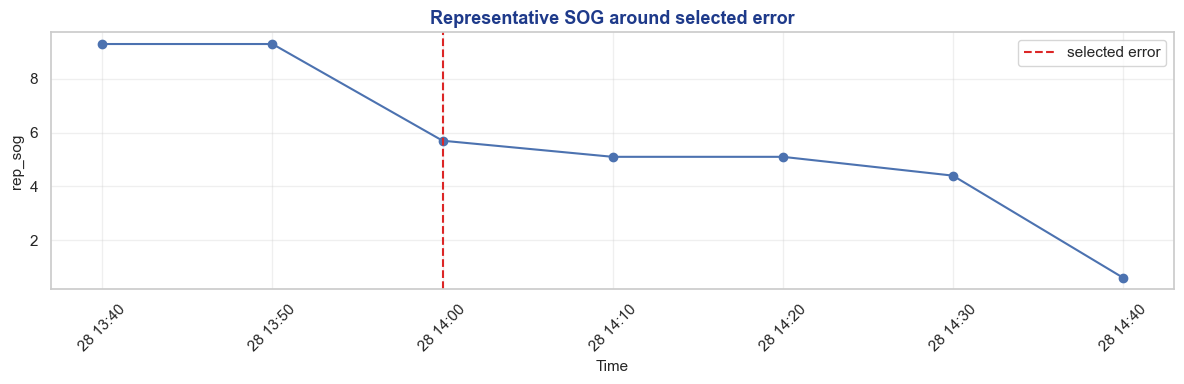

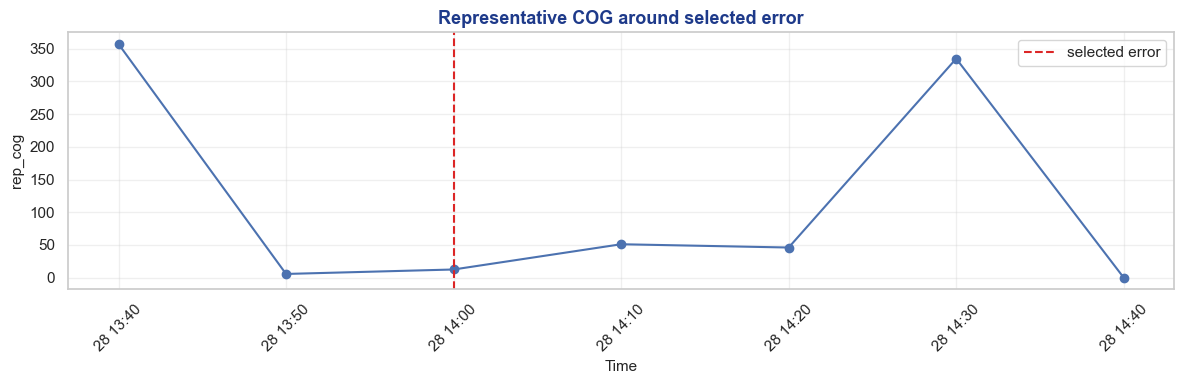

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15B — Inspect one selected vessel/time neighborhood
# ─────────────────────────────────────────────────────────────────────────────
def inspect_vessel_neighborhood(
    selected_row,
    df_eval,
    mmsi_col="MMSI",
    time_col="slice_start",
    minutes_before=60,
    minutes_after=60,
):
    """Return nearby slices for the same vessel around one selected validation row."""
    if mmsi_col not in df_eval.columns or time_col not in df_eval.columns:
        raise ValueError(f"Diagnostic dataframe must contain {mmsi_col!r} and {time_col!r}.")

    selected_mmsi = selected_row[mmsi_col]
    selected_time = pd.to_datetime(selected_row[time_col])

    start_time = selected_time - pd.Timedelta(minutes=minutes_before)
    end_time = selected_time + pd.Timedelta(minutes=minutes_after)

    neighborhood = df_eval[
        (df_eval[mmsi_col] == selected_mmsi) &
        (pd.to_datetime(df_eval[time_col]) >= start_time) &
        (pd.to_datetime(df_eval[time_col]) <= end_time)
    ].copy()

    neighborhood[time_col] = pd.to_datetime(neighborhood[time_col])
    neighborhood = neighborhood.sort_values(time_col).reset_index(drop=True)

    print(f"MMSI: {selected_mmsi}")
    print(f"Selected time: {selected_time}")
    print(f"Window: {start_time} to {end_time}")
    print(f"Rows found: {len(neighborhood)}")
    return neighborhood


def plot_vessel_neighborhood(
    neighborhood,
    selected_row=None,
    time_col="slice_start",
    sog_col="rep_sog",
    cog_col="rep_cog",
):
    """Plot representative SOG and COG around a selected error sample."""
    if len(neighborhood) == 0:
        print("No neighborhood rows to plot.")
        return

    neighborhood = neighborhood.copy()
    neighborhood[time_col] = pd.to_datetime(neighborhood[time_col])
    selected_time = pd.to_datetime(selected_row[time_col]) if selected_row is not None and time_col in selected_row else None

    if sog_col in neighborhood.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(neighborhood[time_col], neighborhood[sog_col], marker="o")
        if selected_time is not None:
            plt.axvline(selected_time, linestyle="--", color=RED, label="selected error")
        plt.title("Representative SOG around selected error", fontweight="bold", color=BLUE_D)
        plt.xlabel("Time")
        plt.ylabel(sog_col)
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    if cog_col in neighborhood.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(neighborhood[time_col], neighborhood[cog_col], marker="o")
        if selected_time is not None:
            plt.axvline(selected_time, linestyle="--", color=RED, label="selected error")
        plt.title("Representative COG around selected error", fontweight="bold", color=BLUE_D)
        plt.xlabel("Time")
        plt.ylabel(cog_col)
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Example: inspect the highest-confidence maneuver → speed-change error.
# Change `cases_to_inspect` to steady_to_other or decelerate_to_maneuver when needed.
cases_to_inspect = maneuver_to_speed_change
# cases_to_inspect = steady_to_other
# cases_to_inspect = decelerate_to_maneuver

if HAS_DIAGNOSTIC_DF and len(cases_to_inspect) > 0 and {"MMSI", "slice_start"}.issubset(inspect_valid_df.columns):
    selected_case = cases_to_inspect.iloc[0]
    neighborhood = inspect_vessel_neighborhood(
        selected_row=selected_case,
        df_eval=inspect_valid_df,
        minutes_before=60,
        minutes_after=60,
    )

    display(neighborhood[[c for c in diagnostic_cols if c in neighborhood.columns]])
    plot_vessel_neighborhood(neighborhood, selected_row=selected_case)
else:
    print("Neighborhood inspection skipped because diagnostic metadata is missing or the selected case group is empty.")


,feature,importance
0,rep_sog_roll3,0.149643
1,rep_sog_roll2,0.068778
2,rep_cog,0.068560
3,sog_stability_score,0.064836
4,rep_sog_delta_1,0.054576
5,cog_circular_std,0.044868
6,sog_mean,0.035249
7,rep_sog,0.032273
8,sog_std,0.023550
9,rep_sog_roll3_std,0.023219


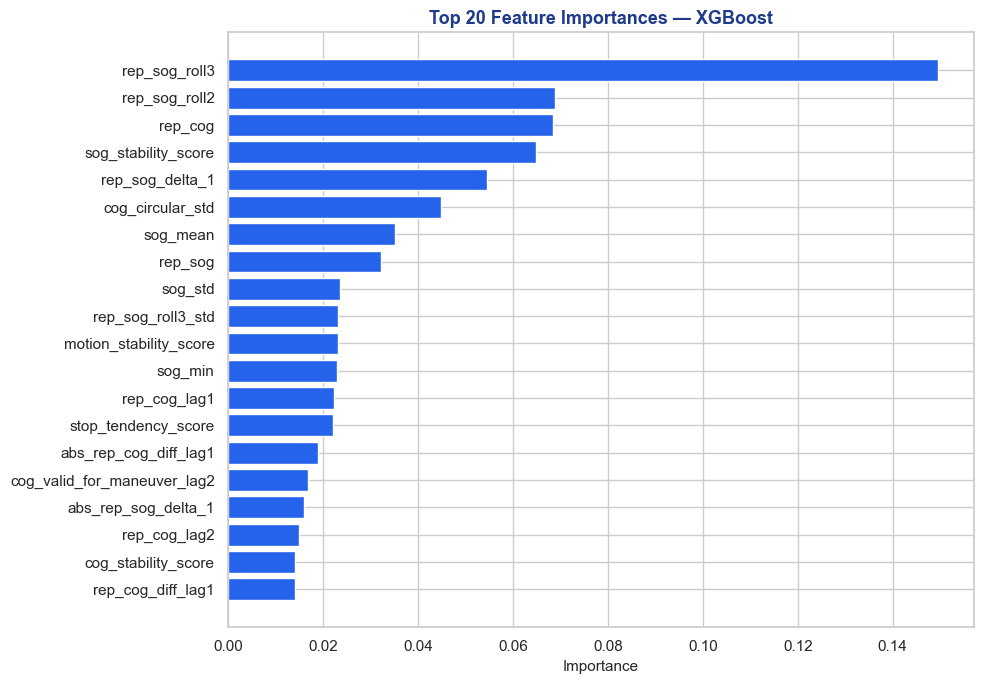

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Feature importance / coefficient view
# ─────────────────────────────────────────────────────────────────────────────
def get_feature_importance(model, feature_names):
    """Return a feature-importance dataframe when the estimator supports it."""
    estimator = model
    if isinstance(model, Pipeline):
        estimator = model.named_steps.get("model", model)

    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        # Multi-class linear model: use mean absolute coefficient across classes.
        imp = np.mean(np.abs(estimator.coef_), axis=0)
    else:
        return None

    return (
        pd.DataFrame({"feature": feature_names, "importance": imp})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

importance_model_name = "XGBoost" if "XGBoost" in trained else best_name
importance_model = trained[importance_model_name]
importance_df = get_feature_importance(importance_model, feature_cols)

if importance_df is None:
    print(f"{importance_model_name} does not expose feature_importances_ or coef_.")
else:
    display(importance_df.head(20))
    fig, ax = plt.subplots(figsize=(10, 7))
    top_imp = importance_df.head(20).iloc[::-1]
    ax.barh(top_imp["feature"], top_imp["importance"], color=BLUE)
    ax.set_title(f"Top 20 Feature Importances — {importance_model_name}", fontweight="bold", color=BLUE_D)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()


---

## 📉 Section 7 — Multi-Class ROC-AUC

ROC-AUC is computed using the **one-vs-rest** strategy. For interpretation, use it as a supporting metric; Macro F1 and per-class recall remain more important for this imbalanced multi-class problem.


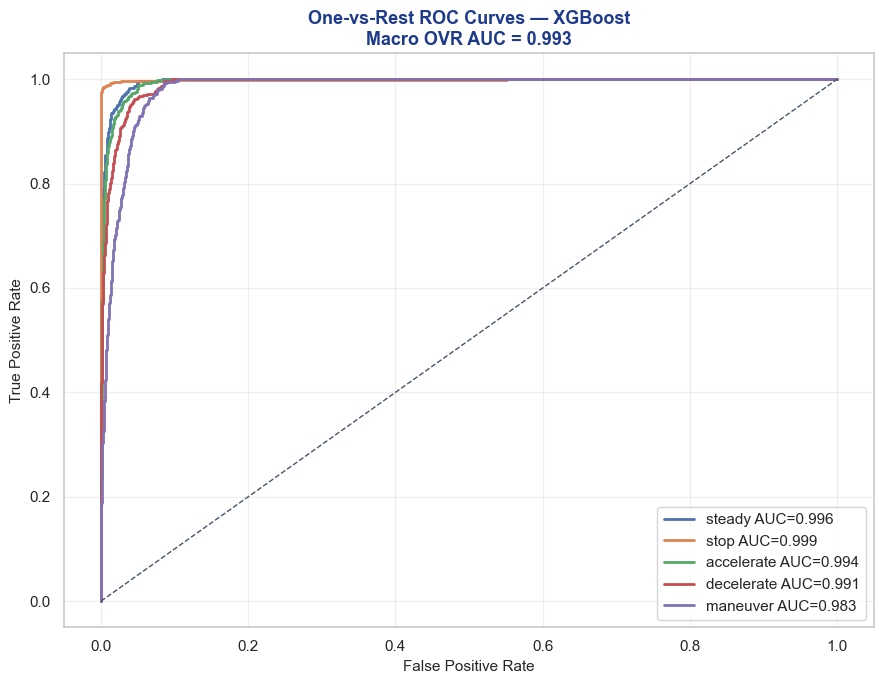

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — One-vs-rest ROC curves for the best model
# ─────────────────────────────────────────────────────────────────────────────
proba_valid = aligned_predict_proba(best_model, X_valid)

if proba_valid is None:
    print(f"{best_name} does not support predict_proba; ROC curves skipped.")
else:
    y_bin = label_binarize(y_valid, classes=CLASS_IDS)

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba_valid[:, i])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f"{class_name} AUC={class_auc:.3f}")

    macro_auc = roc_auc_score(
        y_valid,
        proba_valid,
        labels=CLASS_IDS,
        multi_class="ovr",
        average="macro",
    )
    ax.plot([0, 1], [0, 1], "--", color=SLATE, linewidth=1)
    ax.set_title(f"One-vs-Rest ROC Curves — {best_name}\nMacro OVR AUC = {macro_auc:.3f}", fontweight="bold", color=BLUE_D)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


---

## 🔄 Section 8 — Cross-Validation on Training Data

This section performs Stratified K-Fold cross-validation on the training set only. Because the project already uses MMSI-held-out validation/test splits, cross-validation here is mainly a stability check, not a replacement for the held-out vessel evaluation.


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Stratified K-Fold CV on a manageable training sample
# ─────────────────────────────────────────────────────────────────────────────
RUN_CV = True
CV_SAMPLE_ROWS = 120_000
CV_FOLDS = 3

if RUN_CV:
    X_cv, y_cv = make_training_sample(X_train, y_train, CV_SAMPLE_ROWS, seed=SEED)
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    # CV can be expensive. Use the top validation models only.
    cv_model_names = model_names[:min(4, len(model_names))]
    cv_scores = {}

    for name in cv_model_names:
        print(f"CV for {name} ...")
        scores = cross_val_score(
            trained[name],
            X_cv,
            y_cv,
            cv=skf,
            scoring="f1_macro",
            n_jobs=-1,
        )
        cv_scores[name] = scores
        print(f"  Macro F1: {scores.mean():.4f} ± {scores.std():.4f}")

    cv_df = pd.DataFrame(cv_scores)
    display(cv_df.describe().T.round(4))
else:
    print("Cross-validation skipped. Set RUN_CV=True to enable.")


CV for XGBoost ...
  Macro F1: 0.7641 ± 0.0056
CV for Hist Gradient Boosting ...
  Macro F1: 0.7628 ± 0.0060
CV for Random Forest ...
  Macro F1: 0.7426 ± 0.0105
CV for Extra Trees ...
  Macro F1: 0.7213 ± 0.0122


,count,mean,std,min,25%,50%,75%,max
XGBoost,3.0,0.7641,0.0068,0.7572,0.7608,0.7643,0.7676,0.7708
Hist Gradient Boosting,3.0,0.7628,0.0073,0.7550,0.7595,0.7640,0.7668,0.7695
Random Forest,3.0,0.7426,0.0129,0.7285,0.7370,0.7455,0.7497,0.7538
Extra Trees,3.0,0.7213,0.0149,0.7045,0.7155,0.7264,0.7297,0.7330


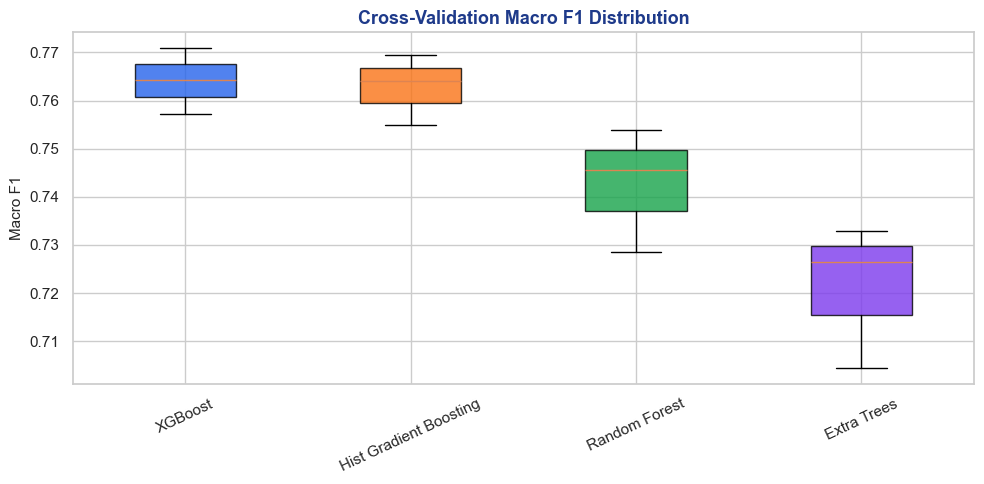

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — CV boxplot
# ─────────────────────────────────────────────────────────────────────────────
if RUN_CV and "cv_scores" in globals() and len(cv_scores) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    data_to_plot = [cv_scores[n] for n in cv_scores.keys()]
    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=list(cv_scores.keys()))

    for patch, color in zip(bp["boxes"], MODEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title("Cross-Validation Macro F1 Distribution", fontweight="bold", color=BLUE_D)
    ax.set_ylabel("Macro F1")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


---

## ⚙️ Section 9 — Optional Hyperparameter Tuning

Tuning can be expensive on AIS data. This section tunes only selected models on a stratified sample of the training data, then evaluates the tuned candidates on the validation set.

Important rule: **the test set is still not used here.**


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Optional hyperparameter tuning
# ─────────────────────────────────────────────────────────────────────────────
RUN_TUNING = False   # Change to True when you want to tune.
TUNE_SAMPLE_ROWS = 150_000

if RUN_TUNING:
    X_tune, y_tune = make_training_sample(X_train, y_train, TUNE_SAMPLE_ROWS, seed=SEED)
    skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    tuning_results = []
    tuned_models = {}

    # Tune HistGradientBoosting
    hgb_param_dist = {
        "max_iter": randint(120, 350),
        "learning_rate": loguniform(0.02, 0.15),
        "max_leaf_nodes": randint(15, 63),
        "l2_regularization": loguniform(1e-4, 1.0),
    }

    hgb_search = RandomizedSearchCV(
        HistGradientBoostingClassifier(random_state=SEED),
        param_distributions=hgb_param_dist,
        n_iter=12,
        scoring="f1_macro",
        cv=skf_tune,
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
    )
    hgb_search.fit(X_tune, y_tune)
    tuned_models["Tuned Hist Gradient Boosting"] = hgb_search.best_estimator_

    # Tune Random Forest
    rf_param_dist = {
        "n_estimators": randint(100, 350),
        "max_depth": [None, 12, 18, 24],
        "min_samples_leaf": randint(5, 60),
        "max_features": ["sqrt", "log2", 0.5, None],
    }

    rf_search = RandomizedSearchCV(
        RandomForestClassifier(class_weight="balanced_subsample", n_jobs=-1, random_state=SEED),
        param_distributions=rf_param_dist,
        n_iter=10,
        scoring="f1_macro",
        cv=skf_tune,
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
    )
    rf_search.fit(X_tune, y_tune)
    tuned_models["Tuned Random Forest"] = rf_search.best_estimator_

    for name, model in tuned_models.items():
        row = evaluate_model(model, X_valid, y_valid)
        row["Model"] = name
        tuning_results.append(row)

    tuning_df = pd.DataFrame(tuning_results).set_index("Model").sort_values("Macro F1", ascending=False)
    print("Tuned model validation results:")
    display(tuning_df.round(4))

    print("\nBest HGB params:", hgb_search.best_params_)
    print("Best RF params:", rf_search.best_params_)
else:
    print("Tuning skipped. Set RUN_TUNING=True to run this section.")


Tuning skipped. Set RUN_TUNING=True to run this section.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Choose final model candidate
# ─────────────────────────────────────────────────────────────────────────────
# Final submission setting:
# Use the best validation ML model as a clean predictive classifier.
# Do not promote rule-priority / guard post-processing to the final test result,
# because those variants use diagnostic target-construction columns that may not
# be available in a real inference setting.

# Final paper setting: use XGBoost raw with deployable current/past features.
# If XGBoost is unavailable, fall back to the selected analysis model.
if "XGBoost" in trained:
    final_name = "XGBoost"
    final_model = trained["XGBoost"]
else:
    final_name = best_name
    final_model = best_model

final_feature_cols = feature_cols
X_test_for_final = X_test
FINAL_POSTPROCESS_MODE = "raw"   # keep final result as deployable pure ML

# If tuning ran and found a better validation Macro F1, keep it optional.
# Default is False to preserve the paper's XGBoost baseline.
ALLOW_TUNED_MODEL_AS_FINAL = False
if ALLOW_TUNED_MODEL_AS_FINAL and "tuning_df" in globals() and len(tuning_df) > 0:
    tuned_best_name = tuning_df.index[0]
    tuned_best_score = tuning_df.loc[tuned_best_name, "Macro F1"]
    base_best_score = results_df.loc[best_name, "Macro F1"]

    if tuned_best_score > base_best_score:
        final_name = tuned_best_name
        final_model = tuned_models[tuned_best_name]
        final_feature_cols = feature_cols
        X_test_for_final = X_test
        FINAL_POSTPROCESS_MODE = "raw"

# Optional diagnostic ablation promotion.
# Keep False for final submission unless you intentionally want to report the
# COG-lag ablation model as the selected raw ML model.
USE_COG_ABLATION_AS_FINAL_IF_BETTER = False

if (
    USE_COG_ABLATION_AS_FINAL_IF_BETTER
    and "cog_ablation_model" in globals()
    and "ablation_compare_df" in globals()
):
    raw_score = ablation_compare_df.loc[f"{best_name} raw", "Macro F1"]
    ablation_label = f"{best_name} without raw lag COG diffs"
    ablation_score = ablation_compare_df.loc[ablation_label, "Macro F1"]

    if ablation_score > raw_score:
        final_name = ablation_label
        final_model = cog_ablation_model
        final_feature_cols = X_train_cog_ablation.columns.tolist()
        X_test_for_final = build_cog_ablation_matrix(X_test, test_df, feature_cols)
        FINAL_POSTPROCESS_MODE = "raw"

# Optional rule-assisted post-processing diagnostics.
# These are intentionally NOT used as the final result for strict predictive ML.
# They can still be kept earlier in the notebook as diagnostic experiments.
USE_RECOMMENDED_PRIORITY_POSTPROCESS_AS_FINAL = False
USE_STEADY_GUARD_AS_FINAL = False
USE_MANEUVER_GUARD_AS_FINAL = False
USE_MANEUVER_DECEL_GUARD_AS_FINAL = False

if USE_RECOMMENDED_PRIORITY_POSTPROCESS_AS_FINAL:
    if USE_MANEUVER_DECEL_GUARD_AS_FINAL:
        final_name = f"{final_name} + recommended conservative priority + maneuver/decel guard"
        FINAL_POSTPROCESS_MODE = "recommended_conservative_with_maneuver_decel_guard"
    elif USE_MANEUVER_GUARD_AS_FINAL:
        final_name = f"{final_name} + recommended conservative priority + maneuver guard"
        FINAL_POSTPROCESS_MODE = "recommended_conservative_with_maneuver_guard"
    elif USE_STEADY_GUARD_AS_FINAL:
        final_name = f"{final_name} + recommended conservative priority + steady guard"
        FINAL_POSTPROCESS_MODE = "recommended_conservative_with_steady_guard"
    else:
        final_name = f"{final_name} + recommended conservative priority"
        FINAL_POSTPROCESS_MODE = "recommended_conservative"

print("Final selected model:", final_name)
print("Final feature count:", len(final_feature_cols))
print("Final post-processing mode:", FINAL_POSTPROCESS_MODE)


Final selected model: XGBoost
Final feature count: 48
Final post-processing mode: raw


---

## ✅ Section 10 — Final Test Evaluation

Only after model selection is complete do we evaluate once on `X_test` / `y_test`. This gives the most honest estimate of generalization to unseen vessels.

For the final submission, this section is configured as a **raw predictive ML test evaluation**:

```python
FINAL_POSTPROCESS_MODE = "raw"
```

The optional hybrid/rule-assisted variants remain useful diagnostics, but they should not be used as deployable inference results because the diagnostic rule flags can include target-construction information from future windows.


In [27]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Final evaluation on test set
# ─────────────────────────────────────────────────────────────────────────────
def predict_with_optional_priority(model, X_eval, y_eval, df_eval, postprocess_mode="raw"):
    """Predict with a model, then optionally apply rule-priority / targeted guard post-processing."""
    base_inspect = build_inspect_df(
        model=model,
        X_eval=X_eval,
        y_eval=y_eval,
        df_eval=df_eval,
        id_to_label=id_to_label,
    )

    if postprocess_mode in [None, "raw", "none"]:
        y_pred = base_inspect["predicted_code"].astype(int)
        inspect_out = base_inspect
    else:
        y_pred = apply_priority_postprocessing(base_inspect, mode=postprocess_mode)
        inspect_out = inspect_with_replaced_predictions(base_inspect, y_pred, postprocess_mode)

    return y_pred.astype(int), inspect_out


y_test_pred, inspect_test_df = predict_with_optional_priority(
    model=final_model,
    X_eval=X_test_for_final,
    y_eval=y_test,
    df_eval=test_df,
    postprocess_mode=FINAL_POSTPROCESS_MODE,
)

test_metrics = metrics_from_predictions(y_test, y_test_pred, final_name)
test_metrics_df = pd.DataFrame([test_metrics]).set_index("Variant").T.rename(columns={final_name: "Test Score"})

display(test_metrics_df.round(4))

print("Classification report on test set:")
print(classification_report(
    y_test,
    y_test_pred,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    zero_division=0,
))


Variant,Test Score
Accuracy,0.9492
Balanced Accuracy,0.7806
Macro Precision,0.6972
Macro Recall,0.7806
Macro F1,0.7314
Weighted F1,0.9505


Classification report on test set:
              precision    recall  f1-score   support

      steady       0.63      0.87      0.73       289
        stop       1.00      0.98      0.99     12834
  accelerate       0.67      0.83      0.74       398
  decelerate       0.64      0.77      0.70       493
    maneuver       0.55      0.45      0.50       546

    accuracy                           0.95     14560
   macro avg       0.70      0.78      0.73     14560
weighted avg       0.95      0.95      0.95     14560



### Executed final-test result summary

This notebook should be run after the two inference-safe features are added. The final submission setting remains the clean raw ML model:

```text
Final selected model: XGBoost
Final post-processing mode: raw
Model feature set: original no-steady-flag features + stop_tendency_score + maneuver_intensity_score
```

The executed metrics are printed by the test-evaluation cell below and exported again in the final paper cross-check cell. Do not copy older 46-feature results from previous notebook runs.


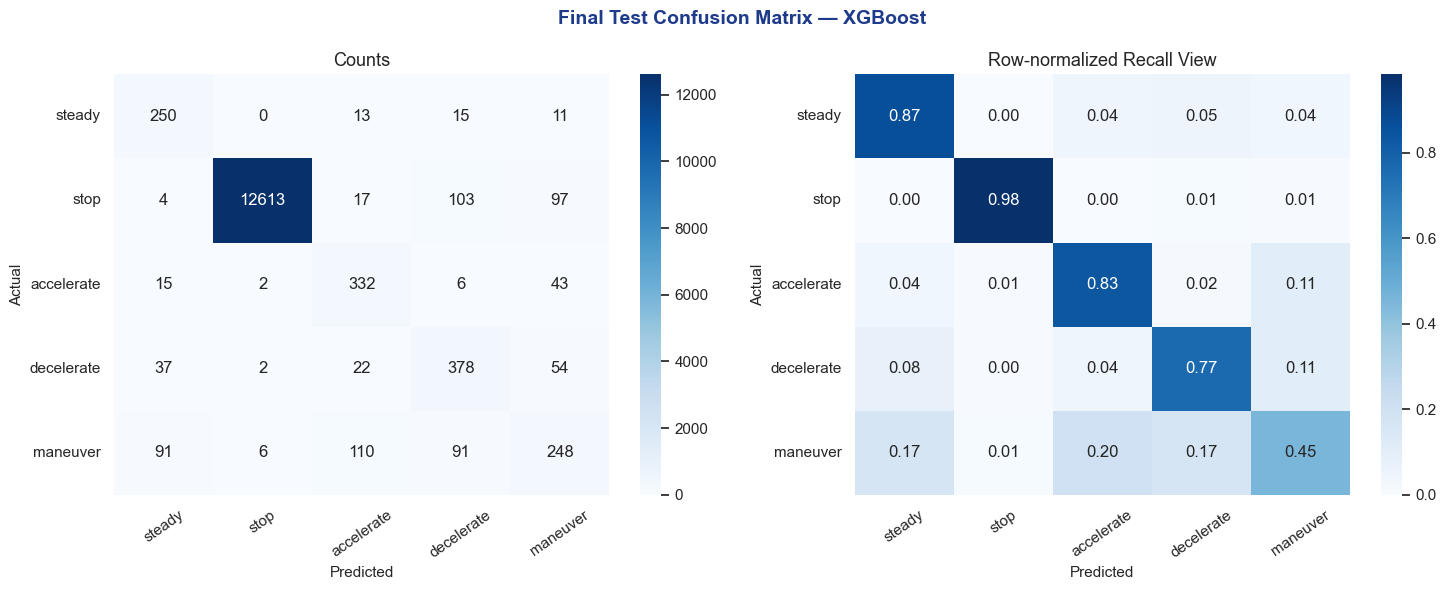

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Final test confusion matrix
# ─────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred, labels=CLASS_IDS)
cm_norm = confusion_matrix(y_test, y_test_pred, labels=CLASS_IDS, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Final Test Confusion Matrix — {final_name}", fontsize=14, fontweight="bold", color=BLUE_D)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title("Row-normalized Recall View")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


## Reviewer addition — final raw test confusion matrix export

This section exports the exact final raw XGBoost confusion matrix used for the paper. Rows are actual classes and columns are predicted classes. The final deployable result remains the raw 48-feature XGBoost model; rule-signature diagnostics are not applied to these predictions.


Final raw test confusion matrix counts


,pred_steady,pred_stop,pred_accelerate,pred_decelerate,pred_maneuver
actual_steady,250,0,13,15,11
actual_stop,4,12613,17,103,97
actual_accelerate,15,2,332,6,43
actual_decelerate,37,2,22,378,54
actual_maneuver,91,6,110,91,248


Final raw test confusion matrix, row-normalized


,pred_steady,pred_stop,pred_accelerate,pred_decelerate,pred_maneuver
actual_steady,0.8651,0.0000,0.0450,0.0519,0.0381
actual_stop,0.0003,0.9828,0.0013,0.0080,0.0076
actual_accelerate,0.0377,0.0050,0.8342,0.0151,0.1080
actual_decelerate,0.0751,0.0041,0.0446,0.7667,0.1095
actual_maneuver,0.1667,0.0110,0.2015,0.1667,0.4542


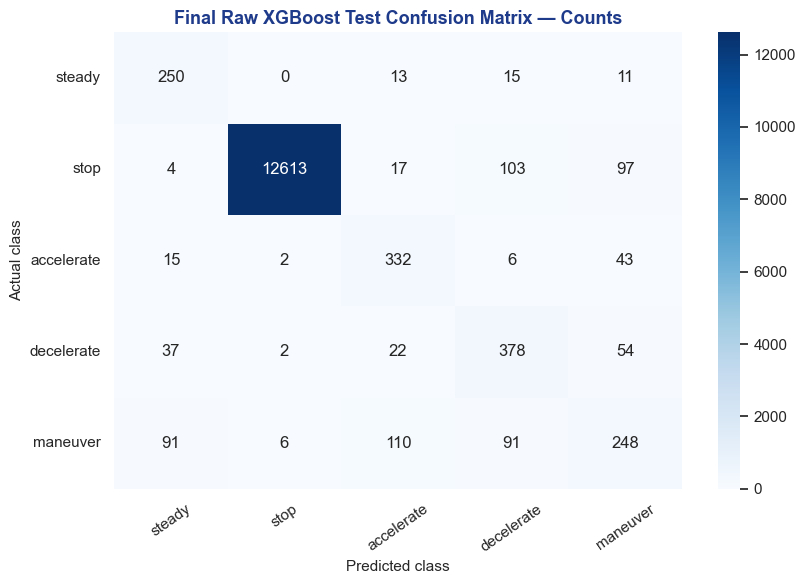

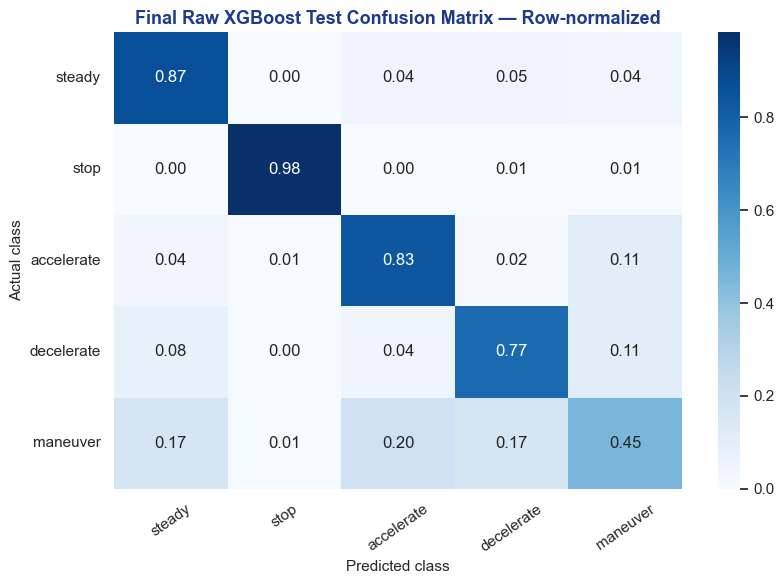

Saved confusion matrix outputs to: /Users/sedatakel/Konya_Gıda_ve_Tarım/CENG8003-Practical Data Science/Term_Project/Vessel Behavior Prediction /ais_ds2_prepared/balanced_train/models/paper_outputs/reviewer_threshold_diagnostics


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# REVIEWER ADDITION — Final raw test confusion matrix table for paper
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = globals().get("OUTPUT_DIR", MODEL_DIR / "paper_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
reviewer_output_dir = OUTPUT_DIR / "reviewer_threshold_diagnostics"
reviewer_output_dir.mkdir(parents=True, exist_ok=True)

# Exact confusion matrix for the final deployable raw model.
cm_raw = confusion_matrix(y_test, y_test_pred, labels=CLASS_IDS)
cm_raw_norm = confusion_matrix(y_test, y_test_pred, labels=CLASS_IDS, normalize="true")

cm_raw_df = pd.DataFrame(
    cm_raw,
    index=[f"actual_{c}" for c in CLASS_NAMES],
    columns=[f"pred_{c}" for c in CLASS_NAMES],
)
cm_raw_norm_df = pd.DataFrame(
    cm_raw_norm,
    index=[f"actual_{c}" for c in CLASS_NAMES],
    columns=[f"pred_{c}" for c in CLASS_NAMES],
)

cm_raw_df.to_csv(reviewer_output_dir / "final_raw_test_confusion_matrix_counts.csv")
cm_raw_norm_df.to_csv(reviewer_output_dir / "final_raw_test_confusion_matrix_row_normalized.csv")

print("Final raw test confusion matrix counts")
display(cm_raw_df)
print("Final raw test confusion matrix, row-normalized")
display(cm_raw_norm_df.round(4))

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(
    cm_raw_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
)
ax.set_title("Final Raw XGBoost Test Confusion Matrix — Counts", fontweight="bold", color=BLUE_D)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig(reviewer_output_dir / "final_raw_test_confusion_matrix_counts.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(
    cm_raw_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
)
ax.set_title("Final Raw XGBoost Test Confusion Matrix — Row-normalized", fontweight="bold", color=BLUE_D)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig(reviewer_output_dir / "final_raw_test_confusion_matrix_row_normalized.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved confusion matrix outputs to:", reviewer_output_dir.resolve())


## Reviewer addition — threshold distribution diagnostics

This section checks whether the rule-derived target thresholds are supported by the observed diagnostic distributions. It does **not** add future-window information to model features. The goal is to justify and discuss the label-construction thresholds more transparently:

- `turn_change_deg_abs`: plot the distribution and mark 35° and the final 45° maneuver threshold.
- `delta_mean_sog`: plot the signed speed-change distribution and mark the accel/decel thresholds at ±0.7, ±1.0, and ±1.5 knots.

For threshold diagnostics, the code first tries to load the natural, imbalanced model-ready split from the sibling `final` folder. If that folder is not available, it falls back to the unchanged validation and test splits, avoiding the balanced training sample so the histogram is not distorted by downsampling.


Threshold diagnostic source: natural model-ready train + validation + test splits
Rows used for threshold diagnostics: 91021
turn_change_deg_abs threshold summary


,source,n,mean,median,p75,p90,p95,p99,share_ge_35deg,share_ge_45deg,share_35_to_45deg,share_45_to_60deg,share_ge_60deg
0,natural model-ready train + validation + test ...,13856,51.2485,35.7626,70.0378,132.0211,158.1024,176.2273,0.5085,0.4168,0.0917,0.119,0.2978


turn_change_deg_abs threshold bands


,turn_change_band_deg,count,proportion
0,"[0, 10)",2226,0.160652
1,"[10, 20)",1911,0.137919
2,"[20, 35)",2673,0.192913
3,"[35, 45)",1271,0.091729
4,"[45, 60)",1649,0.119010
5,"[60, 90)",1551,0.111937
6,"[90, 180)",2575,0.185840


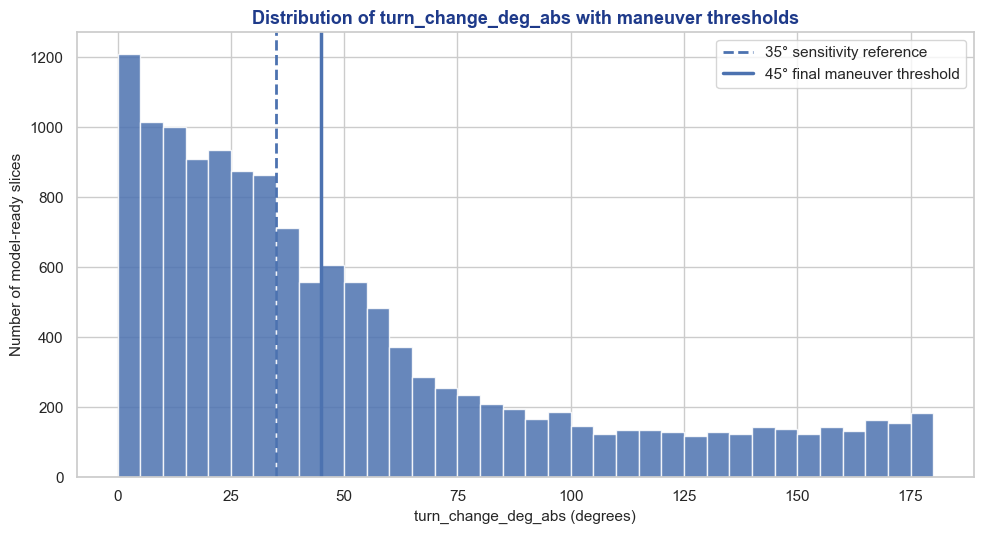

turn_change_deg_abs by target label


,target_label,n,median,p75,p90,p95,share_ge_45
0,accelerate,3015,22.3937,32.5013,39.1208,41.6365,0.0
1,decelerate,3205,23.5987,33.6325,39.8440,42.4129,0.0
2,maneuver,5775,82.2370,129.6117,161.9545,172.0397,1.0
3,steady,1861,8.5111,17.0522,25.9971,30.5185,0.0


delta_mean_sog threshold summary


,source,n,mean,median,p05,p10,p90,p95,abs_median,abs_p75,abs_p90,abs_p95,share_abs_ge_0p7,share_abs_ge_1p0,share_abs_ge_1p5,share_pos_ge_0p7,share_neg_le_minus_0p7
0,natural model-ready train + validation + test ...,91021,-0.1514,0.0,-2.975,-0.275,0.05,1.475,0.0,0.05,2.325,4.95,0.1444,0.1385,0.1229,0.0585,0.0859


abs(delta_mean_sog) threshold bands


,abs_delta_mean_sog_band,count,proportion
0,abs < 0.7,77874,0.855561
1,0.7 <= abs < 1.0,543,0.005966
2,1.0 <= abs < 1.5,1415,0.015546
3,abs >= 1.5,11189,0.122928


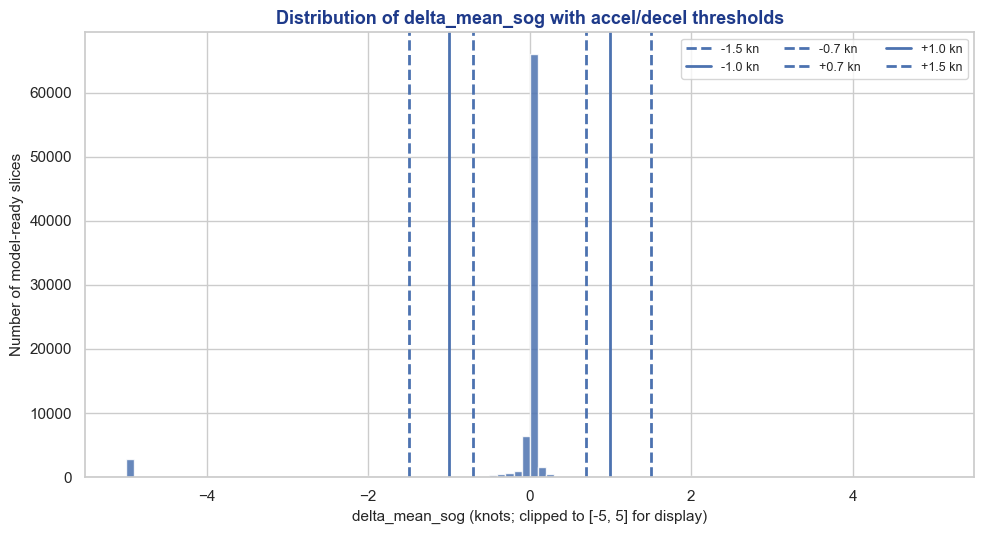

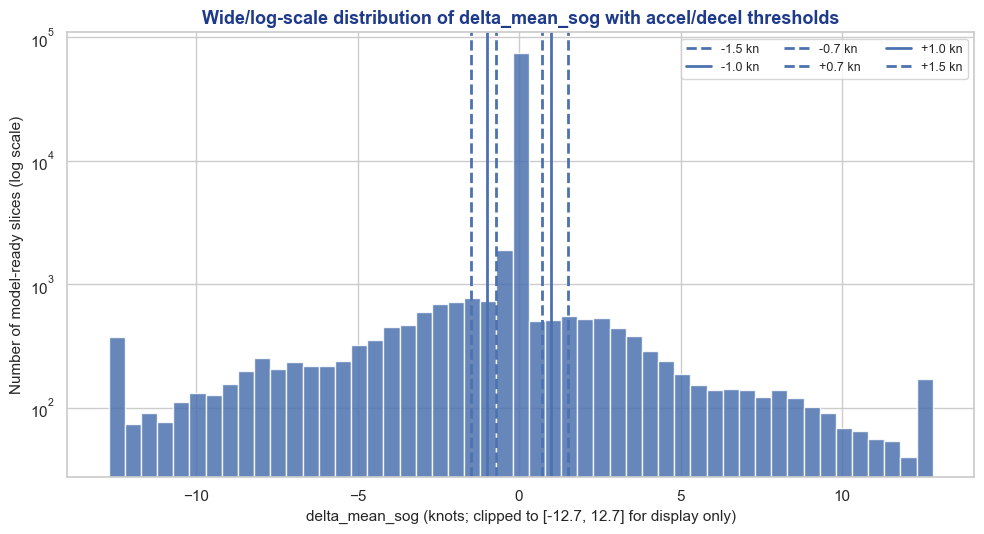

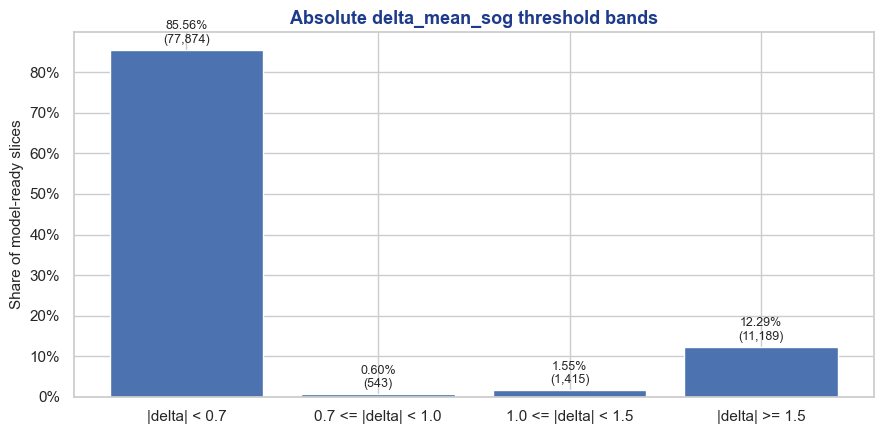

Speed regime counts used in threshold diagnostics


,speed_regime,count
0,low,77196
1,mid,10623
2,high,3202


Saved threshold diagnostic outputs to: /Users/sedatakel/Konya_Gıda_ve_Tarım/CENG8003-Practical Data Science/Term_Project/Vessel Behavior Prediction /ais_ds2_prepared/balanced_train/models/paper_outputs/reviewer_threshold_diagnostics
Summary text: /Users/sedatakel/Konya_Gıda_ve_Tarım/CENG8003-Practical Data Science/Term_Project/Vessel Behavior Prediction /ais_ds2_prepared/balanced_train/models/paper_outputs/reviewer_threshold_diagnostics/threshold_diagnostics_summary_for_paper.txt


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# REVIEWER ADDITION — Threshold distribution histograms for target construction
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = globals().get("OUTPUT_DIR", MODEL_DIR / "paper_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
reviewer_output_dir = OUTPUT_DIR / "reviewer_threshold_diagnostics"
reviewer_output_dir.mkdir(parents=True, exist_ok=True)


def _load_df_from_dir(base_dir: Path, name: str):
    """Load a dataframe from a specified directory without changing FINAL_DIR."""
    csv_path = base_dir / f"{name}.csv"
    parquet_path = base_dir / f"{name}.parquet"
    pickle_path = base_dir / f"{name}.pkl"
    if csv_path.exists():
        return pd.read_csv(csv_path, low_memory=False)
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)
    raise FileNotFoundError(f"Could not find {name} under {base_dir.resolve()}")

# Prefer the natural, imbalanced model-ready split if it exists.
# In this project, FINAL_DIR usually points to .../balanced_train, while the sibling
# .../final directory preserves the original train distribution.
threshold_source = "unchanged validation + test splits"
try:
    natural_dir = FINAL_DIR.parent / "final"
    natural_train_df = parse_datetime_columns(_load_df_from_dir(natural_dir, "train_df"))
    natural_valid_df = parse_datetime_columns(_load_df_from_dir(natural_dir, "valid_df"))
    natural_test_df = parse_datetime_columns(_load_df_from_dir(natural_dir, "test_df"))
    threshold_df = pd.concat([natural_train_df, natural_valid_df, natural_test_df], ignore_index=True)
    threshold_source = "natural model-ready train + validation + test splits"
except Exception as exc:
    print("Natural final split could not be loaded; falling back to validation + test only.")
    print("Reason:", repr(exc))
    threshold_df = pd.concat([valid_df, test_df], ignore_index=True)

print("Threshold diagnostic source:", threshold_source)
print("Rows used for threshold diagnostics:", len(threshold_df))

# Target labels are optional in diagnostic dataframes; attach readable class if target_code is present.
if "target_code" in threshold_df.columns and "target_label" not in threshold_df.columns:
    threshold_df["target_label"] = pd.to_numeric(threshold_df["target_code"], errors="coerce").map(id_to_label)

# -----------------------------------------------------------------------------
# 1) Maneuver threshold diagnostic: turn_change_deg_abs
# -----------------------------------------------------------------------------
if "turn_change_deg_abs" not in threshold_df.columns:
    raise ValueError("turn_change_deg_abs is missing from diagnostic dataframe. Re-run preprocessing/training exports.")

turn = pd.to_numeric(threshold_df["turn_change_deg_abs"], errors="coerce").dropna()
turn = turn[(turn >= 0) & (turn <= 180)]

turn_summary = pd.DataFrame([{
    "source": threshold_source,
    "n": int(turn.shape[0]),
    "mean": float(turn.mean()),
    "median": float(turn.median()),
    "p75": float(turn.quantile(0.75)),
    "p90": float(turn.quantile(0.90)),
    "p95": float(turn.quantile(0.95)),
    "p99": float(turn.quantile(0.99)),
    "share_ge_35deg": float((turn >= 35).mean()),
    "share_ge_45deg": float((turn >= 45).mean()),
    "share_35_to_45deg": float(((turn >= 35) & (turn < 45)).mean()),
    "share_45_to_60deg": float(((turn >= 45) & (turn < 60)).mean()),
    "share_ge_60deg": float((turn >= 60).mean()),
}])
turn_summary.to_csv(reviewer_output_dir / "turn_change_threshold_summary.csv", index=False)

turn_band = pd.cut(
    turn,
    bins=[0, 10, 20, 35, 45, 60, 90, 180],
    include_lowest=True,
    right=False,
).value_counts(sort=False).rename_axis("turn_change_band_deg").reset_index(name="count")
turn_band["proportion"] = turn_band["count"] / turn_band["count"].sum()
turn_band.to_csv(reviewer_output_dir / "turn_change_threshold_bands.csv", index=False)

print("turn_change_deg_abs threshold summary")
display(turn_summary.round(4))
print("turn_change_deg_abs threshold bands")
display(turn_band)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(turn, bins=np.arange(0, 181, 5), alpha=0.85, edgecolor="white")
ax.axvline(35, linestyle="--", linewidth=2, label="35° sensitivity reference")
ax.axvline(45, linestyle="-", linewidth=2.5, label="45° final maneuver threshold")
ax.set_title("Distribution of turn_change_deg_abs with maneuver thresholds", fontweight="bold", color=BLUE_D)
ax.set_xlabel("turn_change_deg_abs (degrees)")
ax.set_ylabel("Number of model-ready slices")
ax.legend()
plt.tight_layout()
fig.savefig(reviewer_output_dir / "hist_turn_change_deg_abs_thresholds.png", dpi=200, bbox_inches="tight")
plt.show()

# Optional class-conditioned view, useful if target labels are available.
if "target_label" in threshold_df.columns:
    class_turn_df = threshold_df[["target_label", "turn_change_deg_abs"]].copy()
    class_turn_df["turn_change_deg_abs"] = pd.to_numeric(class_turn_df["turn_change_deg_abs"], errors="coerce")
    class_turn_df = class_turn_df.dropna()
    class_turn_df = class_turn_df[(class_turn_df["turn_change_deg_abs"] >= 0) & (class_turn_df["turn_change_deg_abs"] <= 180)]
    class_turn_summary = (
        class_turn_df.groupby("target_label")["turn_change_deg_abs"]
        .agg(n="count", median="median", p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.90), p95=lambda s: s.quantile(0.95), share_ge_45=lambda s: (s >= 45).mean())
        .reset_index()
    )
    class_turn_summary.to_csv(reviewer_output_dir / "turn_change_by_target_summary.csv", index=False)
    print("turn_change_deg_abs by target label")
    display(class_turn_summary.round(4))

# -----------------------------------------------------------------------------
# 2) Accel/decel threshold diagnostic: delta_mean_sog
# -----------------------------------------------------------------------------
if "delta_mean_sog" not in threshold_df.columns:
    raise ValueError("delta_mean_sog is missing from diagnostic dataframe. Re-run preprocessing/training exports.")

delta = pd.to_numeric(threshold_df["delta_mean_sog"], errors="coerce").dropna()
# Keep all values for summaries, but use a clipped range for readable visualization.
delta_abs = delta.abs()

delta_summary = pd.DataFrame([{
    "source": threshold_source,
    "n": int(delta.shape[0]),
    "mean": float(delta.mean()),
    "median": float(delta.median()),
    "p05": float(delta.quantile(0.05)),
    "p10": float(delta.quantile(0.10)),
    "p90": float(delta.quantile(0.90)),
    "p95": float(delta.quantile(0.95)),
    "abs_median": float(delta_abs.median()),
    "abs_p75": float(delta_abs.quantile(0.75)),
    "abs_p90": float(delta_abs.quantile(0.90)),
    "abs_p95": float(delta_abs.quantile(0.95)),
    "share_abs_ge_0p7": float((delta_abs >= 0.7).mean()),
    "share_abs_ge_1p0": float((delta_abs >= 1.0).mean()),
    "share_abs_ge_1p5": float((delta_abs >= 1.5).mean()),
    "share_pos_ge_0p7": float((delta >= 0.7).mean()),
    "share_neg_le_minus_0p7": float((delta <= -0.7).mean()),
}])
delta_summary.to_csv(reviewer_output_dir / "delta_mean_sog_threshold_summary.csv", index=False)

abs_delta_band = pd.cut(
    delta_abs,
    bins=[0, 0.7, 1.0, 1.5, np.inf],
    include_lowest=True,
    right=False,
    labels=["abs < 0.7", "0.7 <= abs < 1.0", "1.0 <= abs < 1.5", "abs >= 1.5"],
).value_counts(sort=False).rename_axis("abs_delta_mean_sog_band").reset_index(name="count")
abs_delta_band["proportion"] = abs_delta_band["count"] / abs_delta_band["count"].sum()
abs_delta_band.to_csv(reviewer_output_dir / "delta_mean_sog_threshold_bands.csv", index=False)

print("delta_mean_sog threshold summary")
display(delta_summary.round(4))
print("abs(delta_mean_sog) threshold bands")
display(abs_delta_band)

fig, ax = plt.subplots(figsize=(10, 5.5))
# Use a zoomed x-range for readability; exported summary above still uses all values.
delta_plot = delta.clip(lower=-5, upper=5)
ax.hist(delta_plot, bins=np.arange(-5, 5.01, 0.1), alpha=0.85, edgecolor="white")
for threshold in [-1.5, -1.0, -0.7, 0.7, 1.0, 1.5]:
    ax.axvline(threshold, linestyle="--" if abs(threshold) != 1.0 else "-", linewidth=2, label=f"{threshold:+.1f} kn")
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), ncol=3, fontsize=9)
ax.set_title("Distribution of delta_mean_sog with accel/decel thresholds", fontweight="bold", color=BLUE_D)
ax.set_xlabel("delta_mean_sog (knots; clipped to [-5, 5] for display)")
ax.set_ylabel("Number of model-ready slices")
plt.tight_layout()
fig.savefig(reviewer_output_dir / "hist_delta_mean_sog_thresholds.png", dpi=200, bbox_inches="tight")
plt.show()

# Reviewer robustness check: wider/log-scale view of delta_mean_sog.
# The clipped [-5, 5] plot is useful for the dense central mass, but it can hide
# the non-negligible abs(delta_mean_sog) >= 1.5 tail. This additional figure keeps
# a wider data-driven range and uses a log-scale y-axis so that tail behavior is visible.
delta_nonan = delta.replace([np.inf, -np.inf], np.nan).dropna()
wide_limit = float(max(5.0, np.nanpercentile(np.abs(delta_nonan), 99.5)))
# Avoid a single extreme outlier making the plot unreadable. The summary tables still use all values.
wide_limit = min(wide_limit, 50.0)
bin_width = 0.25 if wide_limit <= 10 else 0.5
wide_bins = np.arange(-wide_limit, wide_limit + bin_width, bin_width)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(delta_nonan.clip(lower=-wide_limit, upper=wide_limit), bins=wide_bins, alpha=0.85, edgecolor="white")
for threshold in [-1.5, -1.0, -0.7, 0.7, 1.0, 1.5]:
    ax.axvline(threshold, linestyle="--" if abs(threshold) != 1.0 else "-", linewidth=2, label=f"{threshold:+.1f} kn")
ax.set_yscale("log")
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), ncol=3, fontsize=9)
ax.set_title("Wide/log-scale distribution of delta_mean_sog with accel/decel thresholds", fontweight="bold", color=BLUE_D)
ax.set_xlabel(f"delta_mean_sog (knots; clipped to [-{wide_limit:.1f}, {wide_limit:.1f}] for display only)")
ax.set_ylabel("Number of model-ready slices (log scale)")
plt.tight_layout()
fig.savefig(reviewer_output_dir / "hist_delta_mean_sog_wide_log_thresholds.png", dpi=200, bbox_inches="tight")
plt.show()

# Reviewer-friendly absolute band chart, which makes the >=1.5 knot tail visible.
fig, ax = plt.subplots(figsize=(9, 4.5))
abs_band_labels = ["|delta| < 0.7", "0.7 <= |delta| < 1.0", "1.0 <= |delta| < 1.5", "|delta| >= 1.5"]
abs_band_props = abs_delta_band["proportion"].astype(float).to_numpy()
abs_band_counts = abs_delta_band["count"].astype(int).to_numpy()
bar_x = np.arange(len(abs_band_labels))
ax.bar(bar_x, abs_band_props)
ax.set_xticks(bar_x)
ax.set_xticklabels(abs_band_labels)
ax.set_ylabel("Share of model-ready slices")
ax.set_title("Absolute delta_mean_sog threshold bands", fontweight="bold", color=BLUE_D)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for x_i, prop_i, count_i in zip(bar_x, abs_band_props, abs_band_counts):
    ax.text(x_i, prop_i + 0.01, f"{prop_i*100:.2f}%\n({count_i:,})", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig.savefig(reviewer_output_dir / "hist_delta_mean_sog_abs_bands.png", dpi=200, bbox_inches="tight")
plt.show()

# Optional speed-regime threshold usage view.
threshold_cols = [c for c in ["speed_regime", "accel_threshold_used", "decel_threshold_used"] if c in threshold_df.columns]
if threshold_cols:
    regime_df = threshold_df[threshold_cols + (["delta_mean_sog"] if "delta_mean_sog" not in threshold_cols else [])].copy()
    regime_df["delta_mean_sog"] = pd.to_numeric(regime_df["delta_mean_sog"], errors="coerce")
    if "accel_threshold_used" in regime_df.columns:
        regime_df["accel_threshold_used"] = pd.to_numeric(regime_df["accel_threshold_used"], errors="coerce")
    if "decel_threshold_used" in regime_df.columns:
        regime_df["decel_threshold_used"] = pd.to_numeric(regime_df["decel_threshold_used"], errors="coerce")
    if "speed_regime" in regime_df.columns:
        speed_regime_counts = regime_df["speed_regime"].value_counts(dropna=False).rename_axis("speed_regime").reset_index(name="count")
        speed_regime_counts.to_csv(reviewer_output_dir / "speed_regime_counts_for_delta_thresholds.csv", index=False)
        print("Speed regime counts used in threshold diagnostics")
        display(speed_regime_counts)

# -----------------------------------------------------------------------------
# Write a small text file with the main paper-use diagnostics.
# -----------------------------------------------------------------------------
summary_lines = []
summary_lines.append(f"Threshold diagnostic source: {threshold_source}")
summary_lines.append(f"Rows used: {len(threshold_df):,}")
summary_lines.append("")
summary_lines.append("turn_change_deg_abs:")
summary_lines.append(turn_summary.round(4).to_string(index=False))
summary_lines.append("")
summary_lines.append("turn_change_deg_abs bands:")
summary_lines.append(turn_band.to_string(index=False))
summary_lines.append("")
summary_lines.append("delta_mean_sog:")
summary_lines.append(delta_summary.round(4).to_string(index=False))
summary_lines.append("")
summary_lines.append("abs(delta_mean_sog) bands:")
summary_lines.append(abs_delta_band.to_string(index=False))

summary_path = reviewer_output_dir / "threshold_diagnostics_summary_for_paper.txt"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved threshold diagnostic outputs to:", reviewer_output_dir.resolve())
print("Summary text:", summary_path.resolve())


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 24 — Save final model and metadata
# ─────────────────────────────────────────────────────────────────────────────
model_path = MODEL_DIR / "final_behavior_classifier.joblib"
metadata_path = MODEL_DIR / "final_behavior_classifier_metadata.json"

# The saved estimator is the underlying ML model. If FINAL_POSTPROCESS_MODE is not raw,
# deployment must also apply the same rule-priority post-processing step after prediction.
joblib.dump(final_model, model_path)

metadata = {
    "final_model_name": final_name,
    "final_postprocess_mode": FINAL_POSTPROCESS_MODE if "FINAL_POSTPROCESS_MODE" in globals() else "raw",
    "prepared_data_dir": str(FINAL_DIR),
    "feature_cols": final_feature_cols if "final_feature_cols" in globals() else feature_cols,
    "target_map": target_map,
    "class_names": CLASS_NAMES,
    "class_ids": CLASS_IDS,
    "split_summary": split_summary,
    "validation_results": results_df.reset_index().to_dict(orient="records"),
    "test_metrics": test_metrics,
    "priority_postprocessing_validation_results": priority_results_df.reset_index().to_dict(orient="records") if "priority_results_df" in globals() else None,
    "cog_lag_ablation_validation_results": ablation_compare_df.reset_index().to_dict(orient="records") if "ablation_compare_df" in globals() else None,
    "deployment_note": "Final raw model uses deployable current/past features only, including stop_tendency_score and maneuver_intensity_score. Rule-assisted/guarded outputs are diagnostic only because their rule flags can include future-window target-construction context.",
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved final post-processing mode:", metadata["final_postprocess_mode"])


Saved model: ais_ds2_prepared/balanced_train/models/final_behavior_classifier.joblib
Saved metadata: ais_ds2_prepared/balanced_train/models/final_behavior_classifier_metadata.json
Saved final post-processing mode: raw


---

## 🧾 Section 11 — Project Takeaways

Use this section for your report/presentation after running the notebook:

1. **Data split:** The DS2 preprocessing notebook uses `mmsi_held_out`, so validation and test contain vessels not seen during training.
2. **Main metric:** Macro F1 is more informative than accuracy because the validation/test sets are highly imbalanced and dominated by `stop`.
3. **Best raw ML model:** In this executed run, **XGBoost** had the highest validation Macro F1 among the trained models.
4. **Expected challenge:** `steady`, `maneuver`, `accelerate`, and `decelerate` are harder than `stop` because their rule-based boundaries can overlap.
5. **Diagnostics:** Rule-overlap summaries are useful for understanding boundary errors, but rule-priority post-processing is diagnostic only because some diagnostic columns, such as future-window stop evidence, come from target-construction context.
6. **Reproducibility:** The final model, feature list, target mapping, and metadata are saved under `FINAL_DIR / models`.


In [32]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 25 — Optional final-model diagnostics on test set
# ─────────────────────────────────────────────────────────────────────────────
# This mirrors the validation inspection after the final model is selected.
# If the final model uses priority post-processing, `inspect_test_df` already contains
# the post-processed predictions created in CELL 22.

print("Test inspection dataframe created:", inspect_test_df.shape)

if "rule_signature" in inspect_test_df.columns:
    show_rule_overlap_summary(inspect_test_df, title=f"Test — {final_name}")

test_maneuver_to_speed_change_all = get_all_confusion_cases(
    inspect_test_df,
    actual_class="maneuver",
    predicted_classes=["accelerate", "decelerate"],
)

test_maneuver_to_steady_all = get_all_confusion_cases(
    inspect_test_df,
    actual_class="maneuver",
    predicted_classes="steady",
)
test_steady_to_other_all = get_all_confusion_cases(
    inspect_test_df,
    actual_class="steady",
    predicted_classes=["stop", "accelerate", "decelerate"],
)
test_decelerate_to_maneuver_all = get_all_confusion_cases(
    inspect_test_df,
    actual_class="decelerate",
    predicted_classes="maneuver",
)

test_maneuver_to_speed_change = get_confusion_cases(
    inspect_test_df,
    actual_class="maneuver",
    predicted_classes=["accelerate", "decelerate"],
    n=20,
)

test_maneuver_to_steady = get_confusion_cases(
    inspect_test_df,
    actual_class="maneuver",
    predicted_classes="steady",
    n=20,
)

test_steady_to_other = get_confusion_cases(
    inspect_test_df,
    actual_class="steady",
    predicted_classes=["stop", "accelerate", "decelerate"],
    n=20,
)

test_decelerate_to_maneuver = get_confusion_cases(
    inspect_test_df,
    actual_class="decelerate",
    predicted_classes="maneuver",
    n=20,
)

show_targeted_error_breakdown(test_maneuver_to_speed_change_all, "TEST Maneuver → accelerate/decelerate", source_label="ALL")
show_targeted_error_breakdown(test_maneuver_to_steady_all, "TEST Maneuver → steady", source_label="ALL")
show_targeted_error_breakdown(test_steady_to_other_all, "TEST Steady → stop/accelerate/decelerate", source_label="ALL")
show_targeted_error_breakdown(test_decelerate_to_maneuver_all, "TEST Decelerate → maneuver", source_label="ALL")

print("\nTest targeted error counts")
display(summarize_targeted_error_counts(inspect_test_df, label=final_name))

print("\nTEST Maneuver → accelerate/decelerate — sample shown by highest confidence")
display(test_maneuver_to_speed_change[[c for c in diagnostic_cols if c in test_maneuver_to_speed_change.columns]])

print("\nTEST Maneuver → steady — sample shown by highest confidence")
display(test_maneuver_to_steady[[c for c in diagnostic_cols if c in test_maneuver_to_steady.columns]])

print("\nTEST Steady → stop/accelerate/decelerate — sample shown by highest confidence")
display(test_steady_to_other[[c for c in diagnostic_cols if c in test_steady_to_other.columns]])

print("\nTEST Decelerate → maneuver — sample shown by highest confidence")
display(test_decelerate_to_maneuver[[c for c in diagnostic_cols if c in test_decelerate_to_maneuver.columns]])


Test inspection dataframe created: (14560, 97)

Test — XGBoost — rule signature distribution


,count
rule_signature,
STOP,12623
DECEL,503
ACCEL,405
STEADY,294
STOP+DECEL,213
DECEL+MANEUVER,204
ACCEL+MANEUVER,176
MANEUVER,138
STOP+ACCEL,4



Test — XGBoost — actual class by rule signature


actual_class,accelerate,decelerate,maneuver,steady,stop
rule_signature,,,,,
ACCEL,0.98,0.00,0.020,0.000,0.000
ACCEL+MANEUVER,0.00,0.00,1.000,0.000,0.000
DECEL,0.00,0.98,0.020,0.000,0.000
DECEL+MANEUVER,0.00,0.00,1.000,0.000,0.000
MANEUVER,0.00,0.00,1.000,0.000,0.000
STEADY,0.00,0.00,0.017,0.983,0.000
STOP,0.00,0.00,0.000,0.000,1.000
STOP+ACCEL,0.25,0.00,0.750,0.000,0.000
STOP+DECEL,0.00,0.00,0.005,0.000,0.995



Test — XGBoost — predicted class by rule signature


...

,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
5232,5232,367433790,2024-01-02 21:50:00,2024-01-02 22:00:00,maneuver,steady,0.987095,maneuver,4,DECEL+MANEUVER,...,82.316406,mid,1.0,1.0,0.00,0.00,-5.544916,-6.117588,4.600,4.600000
5190,5190,367411870,2023-12-31 17:00:00,2023-12-31 17:10:00,maneuver,steady,0.968887,maneuver,4,DECEL+MANEUVER,...,100.527542,mid,1.0,1.0,-0.10,0.10,8.976741,4.249875,9.450,9.433333
3085,3085,367109110,2024-01-30 14:20:00,2024-01-30 14:30:00,maneuver,steady,0.953139,maneuver,4,MANEUVER,...,45.775836,mid,1.0,1.0,-0.10,-0.10,31.192278,5.218161,7.250,7.300000
6334,6334,367587710,2024-01-01 22:10:00,2024-01-01 22:20:00,maneuver,steady,0.952385,maneuver,4,MANEUVER,...,66.118658,mid,1.0,1.0,0.00,0.00,-1.436645,175.250000,9.700,9.700000
8054,8054,367743960,2024-01-07 09:10:00,2024-01-07 09:20:00,maneuver,steady,0.948691,maneuver,4,MANEUVER,...,106.208111,low,0.7,0.7,0.00,0.10,3.224496,-167.367432,2.900,2.866667
7976,7976,367743960,2024-01-01 03:20:00,2024-01-01 03:30:00,maneuver,steady,0.947663,maneuver,4,MANEUVER,...,161.805430,low,0.7,0.7,0.00,0.00,6.685541,-1.356137,2.800,2.800000
4729,4729,367330830,2024-01-20 07:50:00,2024-01-20 08:00:00,maneuver,steady,0.944673,maneuver,4,DECEL+MANEUVER,...,68.170448,mid,1.0,1.0,-0.10,-0.10,11.278757,9.992750,9.450,9.500000
1412,1412,338878000,2024-01-21 15:20:00,2024-01-21 15:30:00,maneuver,steady,0.943859,maneuver,4,DECEL+MANEUVER,...,175.407712,mid,1.0,1.0,0.05,0.60,-4.324312,-14.703049,7.125,6.916667
3056,3056,367109110,2023-12-31 03:40:00,2023-12-31 03:50:00,maneuver,steady,0.941190,maneuver,4,MANEUVER,...,46.190934,mid,1.0,1.0,0.05,-0.15,4.233956,5.727776,5.275,5.316667
8055,8055,367743960,2024-01-07 09:20:00,2024-01-07 09:30:00,maneuver,steady,0.941157,maneuver,4,MANEUVER,...,170.293641,low,0.7,0.7,-0.05,0.00,15.526191,3.224496,2.875,2.883333



TEST Steady → stop/accelerate/decelerate — sample shown by highest confidence


,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
7803,7803,367682410,2023-12-31 15:40:00,2023-12-31 15:50:00,steady,accelerate,0.896221,steady,0,STEADY,...,11.682786,mid,1.0,1.0,0.05,NaN,-24.827015,NaN,5.475,5.475000
4733,4733,367330830,2024-01-26 04:30:00,2024-01-26 04:40:00,steady,accelerate,0.891578,steady,0,STEADY,...,23.459198,mid,1.0,1.0,-1.05,0.00,179.451012,29.943459,5.675,5.850000
2325,2325,367086440,2024-01-08 04:50:00,2024-01-08 05:00:00,steady,decelerate,0.879556,steady,0,STEADY,...,29.686950,mid,1.0,1.0,-2.05,-0.10,1.523069,-0.350231,6.675,7.050000
3,3,210328000,2024-01-13 12:20:00,2024-01-13 12:30:00,steady,decelerate,0.815872,steady,0,STEADY,...,6.100319,mid,1.0,1.0,0.05,0.95,19.022719,12.504518,6.775,6.450000
7802,7802,367682410,2023-12-31 15:30:00,2023-12-31 15:40:00,steady,accelerate,0.789103,steady,0,STEADY,...,22.925872,mid,1.0,1.0,NaN,NaN,NaN,NaN,5.450,5.450000
6345,6345,367587710,2024-01-27 17:40:00,2024-01-27 17:50:00,steady,decelerate,0.786185,steady,0,STEADY,...,33.342494,mid,1.0,1.0,-0.50,0.10,-21.206767,-3.067750,7.750,7.800000
1691,1691,366484000,2024-01-06 21:50:00,2024-01-06 22:00:00,steady,accelerate,0.734000,steady,0,STEADY,...,0.400000,mid,1.0,1.0,0.20,3.50,2.066670,16.362169,9.900,8.700000
1824,1824,366982350,2024-01-01 21:50:00,2024-01-01 22:00:00,steady,decelerate,0.709755,steady,0,STEADY,...,8.552024,high,1.5,1.5,0.20,2.50,-8.271438,179.855323,16.400,15.533333
1463,1463,338878000,2024-01-29 04:10:00,2024-01-29 04:20:00,steady,decelerate,0.696218,steady,0,STEADY,...,29.942142,mid,1.0,1.0,-0.30,-0.10,30.824511,-2.801880,5.950,6.033333
1655,1655,366484000,2024-01-05 18:40:00,2024-01-05 18:50:00,steady,decelerate,0.668354,steady,0,STEADY,...,4.432776,high,1.5,1.5,-0.40,0.45,177.242842,0.232144,10.200,10.116667



TEST Decelerate → maneuver — sample shown by highest confidence


,eval_row_id,MMSI,slice_start,slice_end,actual_class,predicted_class,pred_confidence,target_class,target_code,rule_signature,...,turn_change_deg_abs,speed_regime,accel_threshold_used,decel_threshold_used,rep_sog_delta_1,rep_sog_delta_2,rep_cog_diff_lag1,rep_cog_diff_lag2,rep_sog_roll2,rep_sog_roll3
1179,1179,338339000,2024-01-06 04:00:00,2024-01-06 04:10:00,decelerate,maneuver,0.926003,decelerate,3,DECEL,...,24.213279,mid,1.0,1.0,-0.75,-0.10,-7.667139,18.006072,5.125,5.283333
7873,7873,367739650,2024-01-22 23:50:00,2024-01-23 00:00:00,decelerate,maneuver,0.898310,decelerate,3,DECEL,...,28.793620,high,1.5,1.5,2.10,0.30,1.141174,-169.484557,16.450,16.000000
1737,1737,366484000,2024-01-20 04:30:00,2024-01-20 04:40:00,decelerate,maneuver,0.877555,decelerate,3,DECEL,...,42.189121,mid,1.0,1.0,-0.80,-0.15,-31.862111,29.478292,5.600,5.783333
1361,1361,338753000,2024-01-26 21:40:00,2024-01-26 21:50:00,decelerate,maneuver,0.876956,decelerate,3,DECEL,...,43.900331,mid,1.0,1.0,-0.50,-3.20,-10.331431,17.408596,6.150,7.300000
10526,10526,368360000,2024-01-07 18:00:00,2024-01-07 18:10:00,decelerate,maneuver,0.803749,decelerate,3,DECEL,...,28.514882,high,1.5,1.5,-5.60,0.25,30.161197,162.892596,15.250,16.100000
5495,5495,367442150,2024-01-17 17:50:00,2024-01-17 18:00:00,decelerate,maneuver,0.791183,decelerate,3,DECEL,...,NaN,high,1.5,1.5,-0.10,-5.50,-15.215724,-26.899974,10.150,12.000000
8083,8083,367743960,2024-01-11 21:30:00,2024-01-11 21:40:00,decelerate,maneuver,0.742584,decelerate,3,DECEL,...,33.967409,mid,1.0,1.0,-0.10,0.05,-28.685129,4.135440,7.950,7.950000
6545,6545,367619370,2024-01-26 17:50:00,2024-01-26 18:00:00,decelerate,maneuver,0.741659,decelerate,3,DECEL,...,28.564206,mid,1.0,1.0,3.30,0.30,-61.061613,-13.668343,7.650,7.000000
7829,7829,367739650,2024-01-07 18:50:00,2024-01-07 19:00:00,decelerate,maneuver,0.723888,decelerate,3,DECEL,...,36.414943,high,1.5,1.5,-13.20,0.90,79.036945,32.985020,16.800,18.700000
7853,7853,367739650,2024-01-20 01:30:00,2024-01-20 01:40:00,decelerate,maneuver,0.716844,decelerate,3,DECEL,...,44.585032,high,1.5,1.5,-14.80,0.80,54.984890,44.467310,15.300,17.500000


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL PAPER CROSS-CHECK — inference-safe feature model and diagnostic hybrid
# ─────────────────────────────────────────────────────────────────────────────
# This cell exports the exact tables needed for the next paper revision.
# The raw model is deployable. The guarded diagnostic rule-assisted result is diagnostic only.

# Robust fallback in case older notebooks did not define OUTPUT_DIR in the configuration cell.
OUTPUT_DIR = globals().get("OUTPUT_DIR", MODEL_DIR / "paper_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
paper_output_dir = OUTPUT_DIR / "inference_safe_feature_run"
paper_output_dir.mkdir(parents=True, exist_ok=True)

# Raw final model metrics on the MMSI-held-out test split
raw_label = f"{final_name} raw + inference-safe features — MMSI-held-out test"
raw_metrics = metrics_from_predictions(y_test, y_test_pred, raw_label)
raw_metrics_df = pd.DataFrame([raw_metrics])
raw_report_dict = classification_report(
    y_test, y_test_pred,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
raw_report_df = pd.DataFrame(raw_report_dict).T

# Diagnostic guarded hybrid on the same test split.
# Not deployable: uses diagnostic rule_signature / rule flags that may include future-window label context.
hybrid_mode = "recommended_conservative_with_maneuver_decel_guard"
hybrid_label = f"{final_name} diagnostic guarded hybrid — same MMSI-held-out test split"
y_test_hybrid, inspect_test_hybrid_df = predict_with_optional_priority(
    model=final_model,
    X_eval=X_test_for_final,
    y_eval=y_test,
    df_eval=test_df,
    postprocess_mode=hybrid_mode,
)
hybrid_metrics = metrics_from_predictions(y_test, y_test_hybrid, hybrid_label)
hybrid_metrics_df = pd.DataFrame([raw_metrics, hybrid_metrics])
hybrid_report_dict = classification_report(
    y_test, y_test_hybrid,
    labels=CLASS_IDS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
hybrid_report_df = pd.DataFrame(hybrid_report_dict).T

# Targeted errors under diagnostic hybrid
diagnostic_hybrid_targeted_errors_df = summarize_targeted_error_counts(
    inspect_test_hybrid_df,
    label=hybrid_label,
)

# Feature importance from XGBoost/final model when available
final_importance_df = get_feature_importance(final_model, final_feature_cols)
if final_importance_df is None and "XGBoost" in trained:
    final_importance_df = get_feature_importance(trained["XGBoost"], feature_cols)

# Save outputs
raw_metrics_df.to_csv(paper_output_dir / "raw_test_metrics_inference_safe_features.csv", index=False)
raw_report_df.to_csv(paper_output_dir / "raw_test_classification_report_inference_safe_features.csv")
hybrid_metrics_df.to_csv(paper_output_dir / "raw_vs_diagnostic_hybrid_test_metrics_inference_safe_features.csv", index=False)
hybrid_report_df.to_csv(paper_output_dir / "diagnostic_hybrid_test_classification_report_inference_safe_features.csv")
diagnostic_hybrid_targeted_errors_df.to_csv(paper_output_dir / "diagnostic_hybrid_test_targeted_errors_inference_safe_features.csv", index=False)
if final_importance_df is not None:
    final_importance_df.to_csv(paper_output_dir / "feature_importance_inference_safe_features.csv", index=False)

print("Final feature count:", len(final_feature_cols))
print("Final model:", final_name)
print("Raw model is deployable: current/past-only features.")
print("Diagnostic hybrid is NOT deployable: rule flags may use future-window target-construction evidence.")
print("Output folder:", paper_output_dir.resolve())

print("\nRaw deployable test metrics:")
display(raw_metrics_df.set_index("Variant").round(4))
print("\nRaw deployable class report:")
display(raw_report_df.round(4))
print("\nRaw vs diagnostic hybrid test metrics:")
display(hybrid_metrics_df.set_index("Variant").round(4))
print("\nDiagnostic hybrid class report:")
display(hybrid_report_df.round(4))
print("\nDiagnostic hybrid targeted error counts:")
display(diagnostic_hybrid_targeted_errors_df)
if final_importance_df is not None:
    print("\nTop-15 feature importance:")
    display(final_importance_df.head(15).round(4))


Final feature count: 48
Final model: XGBoost
Raw model is deployable: current/past-only features.
Diagnostic hybrid is NOT deployable: rule flags may use future-window target-construction evidence.
Output folder: /Users/sedatakel/Konya_Gıda_ve_Tarım/CENG8003-Practical Data Science/Term_Project/Vessel Behavior Prediction /ais_ds2_prepared/balanced_train/models/paper_outputs/inference_safe_feature_run

Raw deployable test metrics:


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Variant,,,,,,
XGBoost raw + inference-safe features — MMSI-held-out test,0.9492,0.7806,0.6972,0.7806,0.7314,0.9505



Raw deployable class report:


,precision,recall,f1-score,support
steady,0.6297,0.8651,0.7289,289.0000
stop,0.9992,0.9828,0.9909,12834.0000
accelerate,0.6721,0.8342,0.7444,398.0000
decelerate,0.6374,0.7667,0.6961,493.0000
maneuver,0.5475,0.4542,0.4965,546.0000
accuracy,0.9492,0.9492,0.9492,0.9492
macro avg,0.6972,0.7806,0.7314,14560.0000
weighted avg,0.9537,0.9492,0.9505,14560.0000



Raw vs diagnostic hybrid test metrics:


...

,precision,recall,f1-score,support
steady,0.7599,0.8651,0.8091,289.0000
stop,0.9992,0.9949,0.9971,12834.0000
accelerate,0.8646,0.8342,0.8491,398.0000
decelerate,0.8696,0.8114,0.8395,493.0000
maneuver,0.7977,0.8883,0.8406,546.0000
accuracy,0.9777,0.9777,0.9777,0.9777
macro avg,0.8582,0.8788,0.8670,14560.0000
weighted avg,0.9788,0.9777,0.9781,14560.0000



Diagnostic hybrid targeted error counts:


,model_or_variant,error_group,count
0,XGBoost diagnostic guarded hybrid — same MMSI-...,maneuver_to_accel_or_decel,29
1,XGBoost diagnostic guarded hybrid — same MMSI-...,steady_to_stop_accel_decel,28
2,XGBoost diagnostic guarded hybrid — same MMSI-...,decelerate_to_maneuver,32



Top-15 feature importance:


,feature,importance
0,rep_sog_roll3,0.1496
1,rep_sog_roll2,0.0688
2,rep_cog,0.0686
3,sog_stability_score,0.0648
4,rep_sog_delta_1,0.0546
5,cog_circular_std,0.0449
6,sog_mean,0.0352
7,rep_sog,0.0323
8,sog_std,0.0235
9,rep_sog_roll3_std,0.0232


---

## Notes on preprocessing consistency and final inference reporting

The consistency fixes are handled in the **preprocessing/data-preparation notebook**, not inside model training:

1. **Narrow label repair:** `steady` rows with essentially zero representative and rolling SOG are relabeled as `stop` during data preparation.
2. **Low-speed COG protection:** COG/turn/heading/course-derived feature values are masked for low-speed rows, and `cog_reliable` is persisted as a model feature.
3. **Rule-overlap diagnostics:** prepared diagnostic dataframes include `rule_signature`, `rule_overlap_count`, and individual rule flags.

The final prepared data already include two deployable current/past-only features; this notebook also recomputes/checks them for backward compatibility:

```text
stop_tendency_score = (rep_sog_roll3 - rep_sog) / (rep_sog_roll3 + 0.1)
maneuver_intensity_score = abs(rep_cog_diff_lag1) / (1 + abs(rep_sog_delta_1))
```

These are intended to transfer the insight from diagnostic rule-overlap errors into features that can be computed at inference time.

### Clean predictive result for submission

For a strict ML prediction task, the final result should be the raw XGBoost model trained on the inference-safe feature matrix. This model uses only current/past AIS features and reports test performance on the MMSI-held-out test split.

### Diagnostic diagnostic rule-assisted result

The notebook may still report optional hybrid variants such as:

```text
XGBoost + recommended conservative priority + maneuver/decel guard
```

These variants apply diagnostic rule-priority corrections such as:

```text
ACCEL+MANEUVER -> maneuver
DECEL+MANEUVER -> maneuver
STOP+DECEL     -> stop
```

They should be discussed only as **rule-assisted diagnostics**, because their correction layer depends on diagnostic target-construction context. In particular, `is_stop_rule` can be based on `future_stop_ratio`, which is not available in real-time inference.
